# Open Source Libraries in APK Files — GitHub Enrichment and Wang & Wu (2022) Health Score

This notebook analyzes `dataset_700.csv`, enriches GitHub repositories, and computes the Wang & Wu (2022) PSR OSS project health score in addition to the existing popularity/activity/fragility analysis.


## 1. Setup

Expected project structure:

```text
project_root/
├── analysis_datasets/
│   └── dataset_700.csv
├── database/
│   └── github_repo_metrics_cache.csv      # created automatically
└── notebooks/
    └── this_notebook.ipynb
```

If your notebook is in the project root instead of a `notebooks/` folder, adjust `PROJECT_ROOT`, `ANALYSIS_DATASETS_DIR`, and `DATABASE_DIR` below.

### GitHub authentication

This notebook reads `GITHUB_TOKEN` from a `.env` file at `../.env`, relative to `PROJECT_ROOT`. Add a line like this to that file:

```bash
GITHUB_TOKEN=ghp_your_token_here
```

For public repositories, a fine-grained token with read-only public access is enough. Do not hard-code your token inside this notebook.



In [1]:
import os
import re
import json
import time
import math
import subprocess
from pathlib import Path
from datetime import datetime, timezone
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 160)

# -------------------------------------------------------------------
# Paths
# -------------------------------------------------------------------
# Use the current working directory as default. If this notebook lives
# inside ./notebooks, uncomment the next line instead:
# PROJECT_ROOT = Path.cwd().resolve().parent
PROJECT_ROOT = Path.cwd().resolve()

ANALYSIS_DATASETS_DIR = PROJECT_ROOT / '..' / 'analysis_datasets'
OUTPUT_DIR = PROJECT_ROOT / '..' / 'analysis_outputs'
DATABASE_DIR = PROJECT_ROOT / '..' / 'database'

DATASET_FILE = ANALYSIS_DATASETS_DIR / 'dataset_700.csv'
TAGGED_APPS_FILE = DATABASE_DIR / 'tagged_apps.csv'
CACHE_FILE = DATABASE_DIR / 'github_repo_metrics_cache.csv'
FAILED_REPOS_FILE = DATABASE_DIR / 'github_repo_metrics_failed.csv'
ENV_FILE = PROJECT_ROOT / '..' / '.env'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATABASE_DIR.mkdir(parents=True, exist_ok=True)


def load_env_file(path: Path) -> dict:
    """Load simple KEY=VALUE pairs from a .env file into os.environ."""
    loaded = {}
    if not path.exists():
        return loaded

    for raw_line in path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        if key:
            os.environ.setdefault(key, value)
            loaded[key] = value
    return loaded


ENV_VARS = load_env_file(ENV_FILE)
GITHUB_TOKEN = os.environ.get('GITHUB_TOKEN')


def save_current_figure(filename: str, output_dir: Path = OUTPUT_DIR, dpi: int = 300) -> Path:
    """Save the current matplotlib figure to OUTPUT_DIR as a PNG and return its path."""
    output_dir.mkdir(parents=True, exist_ok=True)
    path = output_dir / filename
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    print('Saved figure:', path)
    return path


print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATASET_FILE:', DATASET_FILE)
print('TAGGED_APPS_FILE:', TAGGED_APPS_FILE)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('DATABASE_DIR:', DATABASE_DIR)
print('CACHE_FILE:', CACHE_FILE)
print('ENV_FILE:', ENV_FILE)
print('GITHUB_TOKEN loaded from .env or environment:', bool(GITHUB_TOKEN))


PROJECT_ROOT: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook
DATASET_FILE: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_datasets/dataset_700.csv
TAGGED_APPS_FILE: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../database/tagged_apps.csv
OUTPUT_DIR: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs
DATABASE_DIR: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../database
CACHE_FILE: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../database/github_repo_metrics_cache.csv
ENV_FILE: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-S

## 2. Load `dataset_700.csv` and transform origin

The `origin` column can contain values such as:

- `fingerprints`
- `license_exposure`
- `fingerprints,license_exposure`

We transform it into two binary columns:

- `origin_fingerprint`
- `origin_license_exposure`


In [2]:
def load_dataset(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Dataset not found: {path}')

    df = pd.read_csv(path)

    # Normalize expected columns in case of small spelling differences.
    if 'library_key' not in df.columns and 'libarary_key' in df.columns:
        # Keep original spelling too, because existing code may reference it.
        df['library_key'] = df['libarary_key']

    required = ['pkg_name', 'repo_url', 'cited', 'origin']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')

    df['origin'] = df['origin'].fillna('').astype(str)
    df['origin_fingerprint'] = df['origin'].str.contains('fingerprints', case=False, na=False).astype(int)
    df['origin_license_exposure'] = df['origin'].str.contains('license_exposure', case=False, na=False).astype(int)
    df['cited'] = pd.to_numeric(df['cited'], errors='coerce').fillna(0).astype(int)

    return df

raw_df = load_dataset(DATASET_FILE)
print(raw_df.shape)
raw_df.head()


(108234, 16)


,pkg_name,repo_host,repo_path,repo_url,cited,origin,libarary_key,library_name,smali_prefix,fingerprint_types,classes_matched,sample_class,sample_class_file,library_key,origin_fingerprint,origin_license_exposure
0,ai.asleep.sleepstar,github.com,BoltsFramework/Bolts-Android,https://github.com/BoltsFramework/Bolts-Android,1,fingerprints,BoltsFramework/Bolts-Android,Bolts-Android,Lbolts/,java_package,36.0,Lbolts/AggregateException;,data/decoded/ai.asleep.sleepstar/smali_classes...,BoltsFramework/Bolts-Android,1,0
1,ai.asleep.sleepstar,github.com,CanHub/Android-Image-Cropper,https://github.com/CanHub/Android-Image-Cropper,1,fingerprints,CanHub/Android-Image-Cropper,Android-Image-Cropper,Lcom/canhub/cropper/,kotlin_package,86.0,Lcom/canhub/cropper/BitmapCroppingWorkerJob$Re...,data/decoded/ai.asleep.sleepstar/smali_classes...,CanHub/Android-Image-Cropper,1,0
2,ai.asleep.sleepstar,github.com,CanHub/Android-Image-Cropper,https://github.com/CanHub/Android-Image-Cropper,1,fingerprints,CanHub/Android-Image-Cropper,Android-Image-Cropper,Lcom/canhub/cropper/utils/,kotlin_package,2.0,Lcom/canhub/cropper/utils/GetFilePathFromUriKt;,data/decoded/ai.asleep.sleepstar/smali_classes...,CanHub/Android-Image-Cropper,1,0
3,ai.asleep.sleepstar,github.com,JetBrains/java-annotations,https://github.com/JetBrains/java-annotations,1,fingerprints,JetBrains/java-annotations,java-annotations,Lorg/jetbrains/annotations/,java_package,30.0,Lorg/jetbrains/annotations/ApiStatus$Available...,data/decoded/ai.asleep.sleepstar/smali_classes...,JetBrains/java-annotations,1,0
4,ai.asleep.sleepstar,github.com,JetBrains/java-annotations,https://github.com/JetBrains/java-annotations,1,fingerprints,JetBrains/java-annotations,java-annotations,Lorg/intellij/lang/annotations/,java_package,27.0,Lorg/intellij/lang/annotations/Flow;,data/decoded/ai.asleep.sleepstar/smali_classes...,JetBrains/java-annotations,1,0


## 3. Normalize GitHub repository identifiers

The dataset may contain GitHub URLs in different fields and formats, for example:

- `https://github.com/square/okio`
- `git+https://github.com/square/okio.git`
- `{'type': 'git', 'url': 'https://github.com/microsoft/react-native-code-push.git'}`
- `square/okio`

The functions below extract a canonical `owner/repo` value named `github_repo_full_name`.


In [3]:

def clean_repo_name(owner: str, repo: str) -> str | None:
    if not owner or not repo:
        return None
    owner = str(owner).strip().strip('/').strip()
    repo = str(repo).strip().strip('/').strip()
    repo = re.sub(r'\.git$', '', repo, flags=re.IGNORECASE)
    repo = repo.split('#')[0].split('?')[0]
    if not owner or not repo:
        return None
    if owner.lower() in {'http:', 'https:', 'github.com', 'www.github.com'}:
        return None
    return f'{owner}/{repo}'


def extract_github_repo_from_text(value) -> str | None:
    # Extract canonical owner/repo from a repo_url-like field.
    if pd.isna(value):
        return None

    text = str(value).strip()
    if not text or text.lower() in {'nan', 'none', 'null'}:
        return None

    # Some rows contain Python-dict-like text with a GitHub URL inside.
    m = re.search(r'https?://github\.com[:/]+([^\s\'\"{}]+)', text, flags=re.IGNORECASE)
    if m:
        parts = m.group(1).strip('/').split('/')
        if len(parts) >= 2:
            return clean_repo_name(parts[0], parts[1])

    # git@github.com:owner/repo.git
    m = re.search(r'git@github\.com:([^/\s]+)/([^\s\'\"]+)', text, flags=re.IGNORECASE)
    if m:
        return clean_repo_name(m.group(1), m.group(2))

    # github.com/owner/repo without protocol
    m = re.search(r'github\.com[:/]+([^/\s]+)/([^\s\'\"]+)', text, flags=re.IGNORECASE)
    if m:
        return clean_repo_name(m.group(1), m.group(2))

    # Plain owner/repo, but avoid JSON-looking, URL-looking, or path-looking values.
    if re.match(r'^[A-Za-z0-9_.-]+/[A-Za-z0-9_.-]+(?:\.git)?$', text):
        owner, repo = text.split('/', 1)
        return clean_repo_name(owner, repo)

    return None


def add_github_repo_identifier(df: pd.DataFrame) -> pd.DataFrame:
    candidate_cols = [
        col for col in ['repo_url', 'repo_path', 'library_key', 'libarary_key']
        if col in df.columns
    ]

    df = df.copy()
    df['github_repo_full_name'] = None

    for col in candidate_cols:
        extracted = df[col].apply(extract_github_repo_from_text)
        df['github_repo_full_name'] = df['github_repo_full_name'].where(
            df['github_repo_full_name'].notna(), extracted
        )

    return df


df = add_github_repo_identifier(raw_df)
print('Rows:', len(df))
print('Rows with GitHub repo:', df['github_repo_full_name'].notna().sum())
print('Unique GitHub repos:', df['github_repo_full_name'].nunique())
df[['pkg_name', 'repo_url', 'repo_path' if 'repo_path' in df.columns else 'repo_url', 'github_repo_full_name']].head(10)


Rows: 108234
Rows with GitHub repo: 106368
Unique GitHub repos: 274


,pkg_name,repo_url,repo_path,github_repo_full_name
0,ai.asleep.sleepstar,https://github.com/BoltsFramework/Bolts-Android,BoltsFramework/Bolts-Android,BoltsFramework/Bolts-Android
1,ai.asleep.sleepstar,https://github.com/CanHub/Android-Image-Cropper,CanHub/Android-Image-Cropper,CanHub/Android-Image-Cropper
2,ai.asleep.sleepstar,https://github.com/CanHub/Android-Image-Cropper,CanHub/Android-Image-Cropper,CanHub/Android-Image-Cropper
3,ai.asleep.sleepstar,https://github.com/JetBrains/java-annotations,JetBrains/java-annotations,JetBrains/java-annotations
4,ai.asleep.sleepstar,https://github.com/JetBrains/java-annotations,JetBrains/java-annotations,JetBrains/java-annotations
5,ai.asleep.sleepstar,https://github.com/InsertKoinIO/koin,InsertKoinIO/koin,InsertKoinIO/koin
6,ai.asleep.sleepstar,https://github.com/InsertKoinIO/koin,InsertKoinIO/koin,InsertKoinIO/koin
7,ai.asleep.sleepstar,https://github.com/InsertKoinIO/koin,InsertKoinIO/koin,InsertKoinIO/koin
8,ai.asleep.sleepstar,https://github.com/InsertKoinIO/koin,InsertKoinIO/koin,InsertKoinIO/koin
9,ai.asleep.sleepstar,https://github.com/InsertKoinIO/koin,InsertKoinIO/koin,InsertKoinIO/koin


## 4. Base repository-level metrics from the APK dataset

Before calling GitHub, we compute dataset-derived metrics for every repository.

### Library Popularity metrics from the APK collection

These reflect popularity **inside your APK collection**, not global GitHub popularity:

- `library_occurrences`: total rows for this repo
- `apk_count`: number of APKs where this repo appears
- `apk_coverage_ratio`: APKs containing this repo / total APKs
- `cited_count`: number of rows with `cited = 1`
- `cited_ratio`: cited rows / total rows for this repo
- `fingerprint_origin_count`
- `license_exposure_origin_count`
- `fingerprint_origin_ratio`
- `license_exposure_origin_ratio`
- `fingerprint_type_count`
- `dominant_fingerprint_type`


In [4]:
def make_repo_dataset_metrics(df: pd.DataFrame) -> pd.DataFrame:
    github_df = df[df['github_repo_full_name'].notna()].copy()
    total_apks = df['pkg_name'].nunique()

    group = github_df.groupby('github_repo_full_name', dropna=False)

    metrics = group.agg(
        library_occurrences=('github_repo_full_name', 'size'),
        apk_count=('pkg_name', 'nunique'),
        cited_count=('cited', 'sum'),
        fingerprint_origin_count=('origin_fingerprint', 'sum'),
        license_exposure_origin_count=('origin_license_exposure', 'sum'),
    ).reset_index()

    metrics['apk_coverage_ratio'] = metrics['apk_count'] / total_apks if total_apks else np.nan
    metrics['cited_ratio'] = metrics['cited_count'] / metrics['library_occurrences']
    metrics['fingerprint_origin_ratio'] = metrics['fingerprint_origin_count'] / metrics['library_occurrences']
    metrics['license_exposure_origin_ratio'] = metrics['license_exposure_origin_count'] / metrics['library_occurrences']

    if 'fingerprint_types' in github_df.columns:
        ft = (
            github_df.dropna(subset=['fingerprint_types'])
            .assign(fingerprint_types=lambda x: x['fingerprint_types'].astype(str))
            .groupby('github_repo_full_name')['fingerprint_types']
            .agg(
                fingerprint_type_count=lambda s: s.nunique(),
                dominant_fingerprint_type=lambda s: s.value_counts().index[0] if len(s) else np.nan,
            )
            .reset_index()
        )
        metrics = metrics.merge(ft, on='github_repo_full_name', how='left')
    else:
        metrics['fingerprint_type_count'] = np.nan
        metrics['dominant_fingerprint_type'] = np.nan

    metrics = metrics.sort_values(['library_occurrences', 'apk_count'], ascending=False)
    return metrics

repo_dataset_metrics = make_repo_dataset_metrics(df)
repo_dataset_metrics.head(20)


,github_repo_full_name,library_occurrences,apk_count,cited_count,fingerprint_origin_count,license_exposure_origin_count,apk_coverage_ratio,cited_ratio,fingerprint_origin_ratio,license_exposure_origin_ratio,fingerprint_type_count,dominant_fingerprint_type
173,material-components/material-components-android,22240,545,10643,22240,19,0.779685,0.478552,1.000000,0.000854,2,java_package
111,facebook/react-native,16154,173,10925,16152,155,0.247496,0.676303,0.999876,0.009595,3,kotlin_package
109,facebook/fresco,13992,337,5607,13992,91,0.482117,0.400729,1.000000,0.006504,3,java_package
26,Kotlin/kotlinx.coroutines,7092,591,6589,7092,1,0.845494,0.929075,1.000000,0.000141,1,kotlin_package
56,androidx/media,6831,141,3274,6831,46,0.201717,0.479286,1.000000,0.006734,4,java_package
80,bumptech/glide,6633,316,3485,6633,3,0.452074,0.525403,1.000000,0.000452,2,java_package
273,zxing/zxing,6086,692,2998,6077,9,0.989986,0.492606,0.998521,0.001479,3,java_package
107,facebook/facebook-android-sdk,4036,327,1985,4036,2,0.467811,0.491824,1.000000,0.000496,3,kotlin_package
127,google/gson,3505,468,2232,3505,190,0.669528,0.636805,1.000000,0.054208,1,java_package
52,airbnb/lottie-android,2057,211,937,2057,9,0.301860,0.455518,1.000000,0.004375,2,java_package


## 5. GitHub API authentication and rate-limit handling

### Important answer to the rate-limit question

- Without authentication, GitHub REST API requests are treated as unauthenticated requests and have a much lower limit.
- To use your GitHub account, this notebook needs a token such as `GITHUB_TOKEN`.
- Your SSH key in `~/.ssh/` does not authenticate `requests.get(...)` calls to the GitHub REST API.
- This notebook reads `GITHUB_TOKEN` from `../.env` first, then falls back to the process environment.

The helper below builds request headers and checks rate-limit headers returned by GitHub.



In [5]:
def make_github_headers() -> dict:
    headers = {
        'Accept': 'application/vnd.github+json',
        'X-GitHub-Api-Version': '2022-11-28',
        'User-Agent': 'apk-open-source-library-analysis-notebook',
    }
    token = GITHUB_TOKEN
    if token:
        headers['Authorization'] = f'Bearer {token}'
    return headers

GITHUB_HEADERS = make_github_headers()
AUTHENTICATED = 'Authorization' in GITHUB_HEADERS
print('GitHub API authenticated:', AUTHENTICATED)
if not AUTHENTICATED:
    print('Tip: add GITHUB_TOKEN=... to ../.env to increase rate limits.')



GitHub API authenticated: True


## 6. GitHub metadata cache with immediate writes

The cache file is `../database/github_repo_metrics_cache.csv`.

Behavior:

1. Load existing cache if it exists.
2. Identify repos missing from the cache.
3. Fetch only missing repos from GitHub.
4. Append each fetched result to the cache immediately.
5. If the notebook is interrupted, already fetched repos remain saved.

There is also a failed-repos file, `../database/github_repo_metrics_failed.csv`, for repos that returned errors such as `404 Not Found`.


In [6]:
GITHUB_CACHE_COLUMNS = [
    'github_repo_full_name',
    'github_owner',
    'github_repo_name',
    'github_html_url',
    'github_api_url',
    'github_found',
    'github_error_status',
    'github_error_message',
    'stars_count',
    'forks_count',
    'watchers_count',
    'subscribers_count',
    'open_issues_count',
    'default_branch',
    'is_archived',
    'is_disabled',
    'is_fork',
    'has_issues',
    'has_projects',
    'has_wiki',
    'license_key',
    'license_name',
    'language',
    'created_at',
    'updated_at',
    'pushed_at',
    'repo_age_days',
    'days_since_update',
    'days_since_push',
    'size_kb',
    'network_count',
    'fetch_timestamp_utc',
    'rate_limit_limit',
    'rate_limit_remaining',
    'rate_limit_reset_utc',
]


def ensure_cache_file(path: Path, columns: list[str]) -> None:
    if not path.exists():
        pd.DataFrame(columns=columns).to_csv(path, index=False)


def load_cache(path: Path) -> pd.DataFrame:
    ensure_cache_file(path, GITHUB_CACHE_COLUMNS)
    cache = pd.read_csv(path)
    for col in GITHUB_CACHE_COLUMNS:
        if col not in cache.columns:
            cache[col] = np.nan
    cache = cache[GITHUB_CACHE_COLUMNS]
    cache = cache.drop_duplicates(subset=['github_repo_full_name'], keep='last')
    return cache


def append_row_to_csv(path: Path, row: dict, columns: list[str]) -> None:
    # Append exactly one row to a CSV immediately.
    ensure_cache_file(path, columns)
    clean_row = {col: row.get(col, np.nan) for col in columns}
    pd.DataFrame([clean_row], columns=columns).to_csv(
        path,
        mode='a',
        index=False,
        header=False,
    )


def deduplicate_cache_file(path: Path, key='github_repo_full_name') -> pd.DataFrame:
    cache = load_cache(path)
    cache = cache.drop_duplicates(subset=[key], keep='last')
    cache.to_csv(path, index=False)
    return cache

cache_df = deduplicate_cache_file(CACHE_FILE)
print('Cached repos:', len(cache_df))
cache_df.head()


Cached repos: 267


,github_repo_full_name,github_owner,github_repo_name,github_html_url,github_api_url,github_found,github_error_status,github_error_message,stars_count,forks_count,watchers_count,subscribers_count,open_issues_count,default_branch,is_archived,is_disabled,is_fork,has_issues,has_projects,has_wiki,license_key,license_name,language,created_at,updated_at,pushed_at,repo_age_days,days_since_update,days_since_push,size_kb,network_count,fetch_timestamp_utc,rate_limit_limit,rate_limit_remaining,rate_limit_reset_utc
0,AzureAD/microsoft-authentication-library-for-js,AzureAD,microsoft-authentication-library-for-js,https://github.com/AzureAD/microsoft-authentic...,https://api.github.com/repos/AzureAD/microsoft...,1,NaN,NaN,4054.0,2710.0,4054.0,124.0,227.0,dev,False,False,False,True,False,True,mit,MIT License,TypeScript,2017-02-24T21:49:17Z,2026-05-02T06:39:14Z,2026-05-01T19:57:49Z,3354.0,1.0,1.0,254786.0,2710.0,2026-05-03T10:40:05.594761+00:00,5000,4997,2026-05-03T11:40:03+00:00
1,BoltsFramework/Bolts-Android,BoltsFramework,Bolts-Android,https://github.com/BoltsFramework/Bolts-Android,https://api.github.com/repos/BoltsFramework/Bo...,1,NaN,NaN,4009.0,523.0,4009.0,241.0,27.0,master,True,False,False,True,True,False,mit,MIT License,Java,2014-01-30T04:58:14Z,2026-05-02T09:59:29Z,2019-03-11T14:59:13Z,4476.0,1.0,2609.0,476.0,523.0,2026-05-03T10:40:06.895065+00:00,5000,4996,2026-05-03T11:40:03+00:00
2,BrianSharpe/Wombat,BrianSharpe,Wombat,https://github.com/BrianSharpe/Wombat,https://api.github.com/repos/BrianSharpe/Wombat,1,NaN,NaN,229.0,16.0,229.0,8.0,1.0,master,False,False,False,True,True,True,NaN,NaN,GLSL,2014-03-29T06:07:31Z,2026-04-13T14:01:39Z,2022-03-04T02:33:19Z,4418.0,19.0,1521.0,18.0,16.0,2026-05-03T10:40:08.128028+00:00,5000,4995,2026-05-03T11:40:03+00:00
3,Caligatio/jsSHA,Caligatio,jsSHA,https://github.com/Caligatio/jsSHA,https://api.github.com/repos/Caligatio/jsSHA,1,NaN,NaN,2265.0,386.0,2265.0,67.0,2.0,master,False,False,False,True,True,True,bsd-3-clause,"BSD 3-Clause ""New"" or ""Revised"" License",TypeScript,2012-07-21T15:43:35Z,2026-04-08T12:14:54Z,2025-12-12T17:20:22Z,5033.0,24.0,141.0,1959.0,386.0,2026-05-03T10:40:09.268576+00:00,5000,4994,2026-05-03T11:40:03+00:00
4,DataDog/dd-trace-php,DataDog,dd-trace-php,https://github.com/DataDog/dd-trace-php,https://api.github.com/repos/DataDog/dd-trace-php,1,NaN,NaN,549.0,175.0,549.0,114.0,141.0,master,False,False,False,True,False,False,other,Other,PHP,2018-02-02T14:21:54Z,2026-04-30T11:30:01Z,2026-05-01T15:47:46Z,3011.0,2.0,1.0,190344.0,175.0,2026-05-03T10:40:10.512435+00:00,5000,4993,2026-05-03T11:40:03+00:00


## 7. GitHub fetch functions

This version fetches only the repository endpoint:

```text
GET /repos/{owner}/{repo}
```

That gives enough data for popularity, activity, and fragility metrics while minimizing API calls. If you later need contributors, releases, commits, or dependency files, add them carefully because each extra endpoint multiplies API usage.


In [7]:

def parse_github_datetime(value):
    if pd.isna(value) or not value:
        return pd.NaT
    return pd.to_datetime(value, utc=True, errors='coerce')


def iso_from_epoch(epoch_value):
    try:
        return datetime.fromtimestamp(int(epoch_value), tz=timezone.utc).isoformat()
    except Exception:
        return np.nan


def rate_limit_info_from_response(response: requests.Response) -> dict:
    return {
        'rate_limit_limit': response.headers.get('x-ratelimit-limit'),
        'rate_limit_remaining': response.headers.get('x-ratelimit-remaining'),
        'rate_limit_reset_utc': iso_from_epoch(response.headers.get('x-ratelimit-reset')),
    }


def build_error_row(repo_full_name: str, response: requests.Response, message: str | None = None) -> dict:
    owner, repo = repo_full_name.split('/', 1)
    try:
        error_json = response.json()
        api_message = error_json.get('message')
    except Exception:
        api_message = response.text[:700] if response.text else None

    row = {
        'github_repo_full_name': repo_full_name,
        'github_owner': owner,
        'github_repo_name': repo,
        'github_html_url': f'https://github.com/{repo_full_name}',
        'github_api_url': f'https://api.github.com/repos/{repo_full_name}',
        'github_found': 0,
        'github_error_status': response.status_code,
        'github_error_message': message or api_message,
        'fetch_timestamp_utc': datetime.now(timezone.utc).isoformat(),
    }
    row.update(rate_limit_info_from_response(response))
    return row


def build_success_row(repo_full_name: str, data: dict, response: requests.Response) -> dict:
    now = pd.Timestamp.now(tz='UTC')
    created_at = parse_github_datetime(data.get('created_at'))
    updated_at = parse_github_datetime(data.get('updated_at'))
    pushed_at = parse_github_datetime(data.get('pushed_at'))

    owner = data.get('owner', {}).get('login')
    repo_name = data.get('name')
    license_obj = data.get('license') or {}

    row = {
        'github_repo_full_name': data.get('full_name', repo_full_name),
        'github_owner': owner,
        'github_repo_name': repo_name,
        'github_html_url': data.get('html_url'),
        'github_api_url': data.get('url'),
        'github_found': 1,
        'github_error_status': np.nan,
        'github_error_message': np.nan,
        'stars_count': data.get('stargazers_count'),
        'forks_count': data.get('forks_count'),
        'watchers_count': data.get('watchers_count'),
        'subscribers_count': data.get('subscribers_count'),
        'open_issues_count': data.get('open_issues_count'),
        'default_branch': data.get('default_branch'),
        'is_archived': data.get('archived'),
        'is_disabled': data.get('disabled'),
        'is_fork': data.get('fork'),
        'has_issues': data.get('has_issues'),
        'has_projects': data.get('has_projects'),
        'has_wiki': data.get('has_wiki'),
        'license_key': license_obj.get('key'),
        'license_name': license_obj.get('name'),
        'language': data.get('language'),
        'created_at': data.get('created_at'),
        'updated_at': data.get('updated_at'),
        'pushed_at': data.get('pushed_at'),
        'repo_age_days': (now - created_at).days if pd.notna(created_at) else np.nan,
        'days_since_update': (now - updated_at).days if pd.notna(updated_at) else np.nan,
        'days_since_push': (now - pushed_at).days if pd.notna(pushed_at) else np.nan,
        'size_kb': data.get('size'),
        'network_count': data.get('network_count'),
        'fetch_timestamp_utc': datetime.now(timezone.utc).isoformat(),
    }
    row.update(rate_limit_info_from_response(response))
    return row


def github_get_repo(repo_full_name: str, headers: dict, sleep_between_requests: float = 0.25) -> dict:
    # Fetch repo metadata from GitHub REST API.
    url = f'https://api.github.com/repos/{repo_full_name}'
    response = requests.get(url, headers=headers, timeout=30)

    # Successful response.
    if response.status_code == 200:
        row = build_success_row(repo_full_name, response.json(), response)
        time.sleep(sleep_between_requests)
        return row

    # Rate limit reached. Save an error row only if this is not a normal rate-limit pause.
    remaining = response.headers.get('x-ratelimit-remaining')
    if response.status_code in {403, 429} and remaining == '0':
        reset_epoch = response.headers.get('x-ratelimit-reset')
        reset_utc = iso_from_epoch(reset_epoch)
        raise RuntimeError(
            f'GitHub primary rate limit reached. Remaining=0. Reset at {reset_utc}. '
            f'Set GITHUB_TOKEN or resume after reset.'
        )

    # Other errors, including 404.
    row = build_error_row(repo_full_name, response)
    time.sleep(sleep_between_requests)
    return row


## 8. Fetch missing GitHub repositories with immediate cache writes

This cell is safe to interrupt. Every successfully fetched or failed repo is appended to the cache immediately.

If you hit a rate limit, set `GITHUB_TOKEN`, restart the notebook kernel, and rerun from the top. Already cached repos will be skipped.


In [8]:
unique_repos = sorted(repo_dataset_metrics['github_repo_full_name'].dropna().unique())
cache_df = deduplicate_cache_file(CACHE_FILE)
cached_repos = set(cache_df['github_repo_full_name'].dropna())
missing_repos = [repo for repo in unique_repos if repo not in cached_repos]

print('Unique repos in dataset:', len(unique_repos))
print('Already cached:', len(cached_repos.intersection(unique_repos)))
print('Missing to fetch:', len(missing_repos))

# Safety knobs
MAX_REPOS_TO_FETCH = None   # set to e.g. 50 for testing, or None for all missing repos
SLEEP_BETWEEN_REQUESTS = 0.25

repos_to_fetch = missing_repos[:MAX_REPOS_TO_FETCH] if MAX_REPOS_TO_FETCH else missing_repos

for i, repo in enumerate(repos_to_fetch, start=1):
    print(f'[{i}/{len(repos_to_fetch)}] Fetching {repo}')
    try:
        row = github_get_repo(repo, GITHUB_HEADERS, sleep_between_requests=SLEEP_BETWEEN_REQUESTS)
        append_row_to_csv(CACHE_FILE, row, GITHUB_CACHE_COLUMNS)
        status = 'OK' if row.get('github_found') == 1 else f"ERROR {row.get('github_error_status')}"
        remaining = row.get('rate_limit_remaining')
        print(f'    saved immediately: {status}; remaining={remaining}')
    except RuntimeError as e:
        print(str(e))
        print('Stopping loop. Rerun after setting GITHUB_TOKEN or after the reset time. Cached rows are preserved.')
        break
    except Exception as e:
        # Save unexpected failure separately so the loop can continue.
        fail_row = {
            'github_repo_full_name': repo,
            'error': repr(e),
            'fetch_timestamp_utc': datetime.now(timezone.utc).isoformat(),
        }
        append_row_to_csv(FAILED_REPOS_FILE, fail_row, ['github_repo_full_name', 'error', 'fetch_timestamp_utc'])
        print(f'    unexpected error saved to failed file: {e}')

cache_df = deduplicate_cache_file(CACHE_FILE)
print('Cache rows after fetch:', len(cache_df))
cache_df.tail()


Unique repos in dataset: 274
Already cached: 0
Missing to fetch: 274
[1/274] Fetching 81813780/AVLoadingIndicatorView
    saved immediately: OK; remaining=4998
[2/274] Fetching AzureAD/microsoft-authentication-library-for-js
    saved immediately: OK; remaining=4997
[3/274] Fetching BoltsFramework/Bolts-Android
    saved immediately: OK; remaining=4996
[4/274] Fetching BrianSharpe/Wombat
    saved immediately: OK; remaining=4995
[5/274] Fetching Caligatio/jsSHA
    saved immediately: OK; remaining=4994
[6/274] Fetching CanHub/Android-Image-Cropper
    saved immediately: OK; remaining=4993
[7/274] Fetching DataDog/dd-trace-php
    saved immediately: OK; remaining=4992
[8/274] Fetching DefinitelyTyped/DefinitelyTyped
    saved immediately: OK; remaining=4991
[9/274] Fetching Dynatrace/dem-license
    saved immediately: OK; remaining=4990
[10/274] Fetching EddyVerbruggen/Calendar-PhoneGap-Plugin
    saved immediately: OK; remaining=4989
[11/274] Fetching EddyVerbruggen/SocialSharing-Phone

,github_repo_full_name,github_owner,github_repo_name,github_html_url,github_api_url,github_found,github_error_status,github_error_message,stars_count,forks_count,watchers_count,subscribers_count,open_issues_count,default_branch,is_archived,is_disabled,is_fork,has_issues,has_projects,has_wiki,license_key,license_name,language,created_at,updated_at,pushed_at,repo_age_days,days_since_update,days_since_push,size_kb,network_count,fetch_timestamp_utc,rate_limit_limit,rate_limit_remaining,rate_limit_reset_utc
269,webcomponents/webcomponentsjs,webcomponents,webcomponentsjs,https://github.com/webcomponents/webcomponentsjs,https://api.github.com/repos/webcomponents/web...,1,NaN,NaN,3858.0,484.0,3858.0,6.0,0.0,master,True,False,False,True,True,True,other,Other,HTML,2014-10-09T18:56:42Z,2026-05-02T10:51:14Z,2019-09-08T23:26:41Z,4230.0,8.0,2435.0,21633.0,484.0,2026-05-10T14:30:39.257835+00:00,5000,4703,2026-05-10T15:27:25+00:00
270,wooorm/bcp-47,wooorm,bcp-47,https://github.com/wooorm/bcp-47,https://api.github.com/repos/wooorm/bcp-47,1,NaN,NaN,75.0,7.0,75.0,1.0,1.0,main,False,False,False,True,False,False,mit,MIT License,JavaScript,2016-02-21T17:42:55Z,2026-03-03T05:30:33Z,2023-11-01T11:28:42Z,3730.0,68.0,921.0,143.0,7.0,2026-05-10T14:30:39.905452+00:00,5000,4702,2026-05-10T15:27:25+00:00
271,svgdotjs/svg.filter.js,svgdotjs,svg.filter.js,https://github.com/svgdotjs/svg.filter.js,https://api.github.com/repos/svgdotjs/svg.filt...,1,NaN,NaN,222.0,53.0,222.0,8.0,20.0,master,False,False,False,True,True,True,mit,MIT License,JavaScript,2013-07-11T13:39:38Z,2026-01-21T16:23:04Z,2025-02-24T16:16:24Z,4686.0,108.0,439.0,371.0,53.0,2026-05-10T14:30:40.770454+00:00,5000,4700,2026-05-10T15:27:25+00:00
272,zloirock/core-js,zloirock,core-js,https://github.com/zloirock/core-js,https://api.github.com/repos/zloirock/core-js,1,NaN,NaN,25499.0,1697.0,25499.0,251.0,44.0,master,False,False,False,True,False,False,mit,MIT License,JavaScript,2013-07-17T16:32:27Z,2026-05-10T13:44:11Z,2026-05-10T13:33:12Z,4679.0,0.0,0.0,95458.0,1697.0,2026-05-10T14:30:41.447156+00:00,5000,4699,2026-05-10T15:27:25+00:00
273,zxing/zxing,zxing,zxing,https://github.com/zxing/zxing,https://api.github.com/repos/zxing/zxing,1,NaN,NaN,33933.0,9433.0,33933.0,1649.0,4.0,master,False,False,False,True,False,True,apache-2.0,Apache License 2.0,Java,2011-10-12T14:07:27Z,2026-05-10T13:42:59Z,2026-05-04T07:31:28Z,5324.0,0.0,6.0,243578.0,9433.0,2026-05-10T14:30:42.123942+00:00,5000,4698,2026-05-10T15:27:25+00:00


## 9. Merge dataset metrics with GitHub metrics

This creates one enriched row per repository.


In [9]:
cache_df = deduplicate_cache_file(CACHE_FILE)
repo_enriched = repo_dataset_metrics.merge(
    cache_df,
    on='github_repo_full_name',
    how='left',
)

print(repo_enriched.shape)
repo_enriched.head(20)


(274, 46)


,github_repo_full_name,library_occurrences,apk_count,cited_count,fingerprint_origin_count,license_exposure_origin_count,apk_coverage_ratio,cited_ratio,fingerprint_origin_ratio,license_exposure_origin_ratio,fingerprint_type_count,dominant_fingerprint_type,github_owner,github_repo_name,github_html_url,github_api_url,github_found,github_error_status,github_error_message,stars_count,forks_count,watchers_count,subscribers_count,open_issues_count,default_branch,is_archived,is_disabled,is_fork,has_issues,has_projects,has_wiki,license_key,license_name,language,created_at,updated_at,pushed_at,repo_age_days,days_since_update,days_since_push,size_kb,network_count,fetch_timestamp_utc,rate_limit_limit,rate_limit_remaining,rate_limit_reset_utc
0,material-components/material-components-android,22240,545,10643,22240,19,0.779685,0.478552,1.000000,0.000854,2,java_package,material-components,material-components-android,https://github.com/material-components/materia...,https://api.github.com/repos/material-componen...,1.0,NaN,NaN,17281.0,3231.0,17281.0,437.0,797.0,master,False,False,False,True,True,False,apache-2.0,Apache License 2.0,Java,2016-12-05T16:11:29Z,2026-05-10T13:06:47Z,2026-05-06T23:08:25Z,3442.0,0.0,3.0,183365.0,3231.0,2026-05-10T14:29:32.247305+00:00,5000.0,4801.0,2026-05-10T15:27:25+00:00
1,facebook/react-native,16154,173,10925,16152,155,0.247496,0.676303,0.999876,0.009595,3,kotlin_package,facebook,react-native,https://github.com/facebook/react-native,https://api.github.com/repos/facebook/react-na...,1.0,NaN,NaN,125775.0,25148.0,125775.0,3533.0,1308.0,main,False,False,False,True,True,True,mit,MIT License,C++,2015-01-09T18:10:16Z,2026-05-10T13:53:56Z,2026-05-09T13:58:06Z,4138.0,0.0,1.0,967451.0,25148.0,2026-05-10T14:28:45.925855+00:00,5000.0,4873.0,2026-05-10T15:27:25+00:00
2,facebook/fresco,13992,337,5607,13992,91,0.482117,0.400729,1.000000,0.006504,3,java_package,facebook,fresco,https://github.com/facebook/fresco,https://api.github.com/repos/facebook/fresco,1.0,NaN,NaN,17150.0,3743.0,17150.0,842.0,258.0,main,False,False,False,True,True,True,mit,MIT License,Java,2015-03-02T09:58:04Z,2026-05-09T18:49:58Z,2026-05-08T13:49:31Z,4087.0,0.0,2.0,80236.0,3743.0,2026-05-10T14:28:44.525436+00:00,5000.0,4875.0,2026-05-10T15:27:25+00:00
3,Kotlin/kotlinx.coroutines,7092,591,6589,7092,1,0.845494,0.929075,1.000000,0.000141,1,kotlin_package,Kotlin,kotlinx.coroutines,https://github.com/Kotlin/kotlinx.coroutines,https://api.github.com/repos/Kotlin/kotlinx.co...,1.0,NaN,NaN,13745.0,1927.0,13745.0,290.0,340.0,master,False,False,False,True,True,False,apache-2.0,Apache License 2.0,Kotlin,2016-06-22T13:49:21Z,2026-05-09T22:25:08Z,2026-05-08T21:18:53Z,3609.0,0.0,1.0,37120.0,1927.0,2026-05-10T14:27:44.285453+00:00,5000.0,4971.0,2026-05-10T15:27:25+00:00
4,androidx/media,6831,141,3274,6831,46,0.201717,0.479286,1.000000,0.006734,4,java_package,androidx,media,https://github.com/androidx/media,https://api.github.com/repos/androidx/media,1.0,NaN,NaN,2807.0,794.0,2807.0,59.0,885.0,release,False,False,False,True,True,False,apache-2.0,Apache License 2.0,Java,2021-09-02T18:42:10Z,2026-05-10T12:48:09Z,2026-05-08T20:13:20Z,1710.0,0.0,1.0,789999.0,794.0,2026-05-10T14:28:05.623804+00:00,5000.0,4938.0,2026-05-10T15:27:25+00:00
5,bumptech/glide,6633,316,3485,6633,3,0.452074,0.525403,1.000000,0.000452,2,java_package,bumptech,glide,https://github.com/bumptech/glide,https://api.github.com/repos/bumptech/glide,1.0,NaN,NaN,35021.0,6176.0,35021.0,1024.0,638.0,master,False,False,False,True,True,True,other,Other,Java,2013-07-08T22:52:33Z,2026-05-10T09:21:56Z,2026-05-08T20:29:31Z,4688.0,0.0,1.0,97826.0,6176.0,2026-05-10T14:28:23.359522+00:00,5000.0,4911.0,2026-05-10T15:27:25+00:00
6,zxing/zxing,6086,692,2998,6077,9,0.989986,0.492606,0.998521,0.001479,3,java_package,zxing,zxing,https://github.com/zxing/zxing,https://api.github.com/repos/zxing/zxing,1.0,NaN,NaN,33933.0,9433.0,33933.0,1649.0,4.0,master,False,False,False,True,False,True,apache-2.0,Apache License 2.0,Java,2011-10-12T14

## 10. Wang & Wu (2022) PSR health score

This section implements the OSS project health score from:

> Wang, H. and Wu, Z. (2022). *A Method to Evaluate the Health of OSS Projects Based on the PSR Model and Combination Weighting*. IEEE SEAI 2022.

The paper defines a Pressure-State-Response (PSR) model with 12 indicators, normalizes positive and negative indicators with min-max normalization, applies the final published layer weights, and calculates:

\[
H_i = \sum_{j=1}^{m} w_j p_{ij}
\]

\[
H = \left(\frac{H_P + H_S + H_R}{3}\right) \times 100
\]

Important implementation notes:

- The paper's model has **12 indicators**, not 16, in the uploaded version.
- The health score is relative to the repository batch being analyzed because min-max normalization uses the observed min and max values across the analyzed repositories.
- GitHub repo URLs and the GitHub token are enough as inputs, but the repo metadata endpoint alone is not enough. This section fetches issues, PRs, contributors, comments, languages, and commits.
- Local clones in `../data/repos/github.com/{owner}/{repo}` are used for commit counts when available. If a repo is not cloned, the notebook falls back to the GitHub API. Optionally, you can allow missing repos to be cloned.


In [10]:
# -------------------------------------------------------------------
# Wang & Wu (2022) PSR health score configuration
# -------------------------------------------------------------------

# Local clone root described in the prompt:
# ../data/repos/github.com/chartjs/awesome
# ../data/repos/github.com/chartjs/Chart.js
LOCAL_REPOS_ROOT = PROJECT_ROOT / '..' / 'data' / 'repos' / 'github.com'

WANG_HEALTH_CACHE_FILE = DATABASE_DIR / 'github_repo_wang2022_health_metrics_cache.csv'
WANG_HEALTH_OUTPUT = OUTPUT_DIR / 'dataset_700_repo_wang2022_health_scores.csv'
WANG_HEALTH_ROW_OUTPUT = OUTPUT_DIR / 'dataset_700_rows_with_wang2022_health_score.csv'

# Safety controls.
# Commit count can be obtained from local clones or GitHub API, so cloning is optional.
CLONE_MISSING_REPOS = False
GIT_CLONE_TIMEOUT_SECONDS = 180

# Issue close time may be expensive for very large projects. The paper used GHTorrent;
# this notebook estimates the mean using up to this many closed issues from GitHub API.
MAX_CLOSED_ISSUES_FOR_CLOSE_TIME = 1000

# Pause between API requests to reduce secondary rate-limit risk.
HEALTH_API_SLEEP_SECONDS = 0.15

# Wang & Wu final combined weights, formula (21).
WANG_WEIGHTS = {
    'pressure': {
        'number_watches': 0.0901,
        'number_forks': 0.1519,
        'number_languages': 0.2291,
        'number_bugs': 0.5285,
    },
    'state': {
        'number_contributors': 0.3147,
        'number_commits': 0.1304,
        'number_comments': 0.0676,
        'number_issues': 0.4871,
    },
    'response': {
        'number_pull_requests': 0.0559,
        'pull_requests_merged': 0.3525,
        'issue_close_open_ratio': 0.4261,
        'issue_close_time_days': 0.1650,
    },
}

# Positive indicators use formula (14); negative indicators use formula (15).
WANG_INDICATOR_DIRECTION = {
    'number_watches': 'positive',
    'number_forks': 'positive',
    'number_languages': 'negative',
    'number_bugs': 'negative',
    'number_contributors': 'positive',
    'number_commits': 'positive',
    'number_comments': 'positive',
    'number_issues': 'positive',
    'number_pull_requests': 'positive',
    'pull_requests_merged': 'positive',
    'issue_close_open_ratio': 'positive',
    'issue_close_time_days': 'negative',
}

WANG_HEALTH_CACHE_COLUMNS = [
    'github_repo_full_name',
    'wang_found',
    'wang_error_message',
    'number_watches',
    'number_forks',
    'number_languages',
    'number_bugs',
    'number_contributors',
    'number_commits',
    'number_comments',
    'number_issues',
    'number_pull_requests',
    'pull_requests_merged',
    'open_issues_for_ratio',
    'closed_issues_for_ratio',
    'issue_close_open_ratio',
    'issue_close_time_days',
    'issue_close_time_issue_count',
    'commit_count_source',
    'local_repo_path',
    'fetch_timestamp_utc',
]

print('LOCAL_REPOS_ROOT:', LOCAL_REPOS_ROOT)
print('WANG_HEALTH_CACHE_FILE:', WANG_HEALTH_CACHE_FILE)
print('WANG_HEALTH_OUTPUT:', WANG_HEALTH_OUTPUT)


LOCAL_REPOS_ROOT: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../data/repos/github.com
WANG_HEALTH_CACHE_FILE: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../database/github_repo_wang2022_health_metrics_cache.csv
WANG_HEALTH_OUTPUT: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/dataset_700_repo_wang2022_health_scores.csv


In [11]:
# -------------------------------------------------------------------
# GitHub API helpers for Wang & Wu indicators
# -------------------------------------------------------------------

def parse_link_header(link_header: str | None) -> dict:
    """Parse GitHub Link header into a dict such as {'last': url, 'next': url}."""
    links = {}
    if not link_header:
        return links
    for part in link_header.split(','):
        part = part.strip()
        if ';' not in part:
            continue
        url_part, rel_part = part.split(';', 1)
        url = url_part.strip().strip('<>').strip()
        rel_match = re.search(r'rel="([^"]+)"', rel_part)
        if rel_match:
            links[rel_match.group(1)] = url
    return links


def page_number_from_url(url: str | None) -> int | None:
    if not url:
        return None
    parsed = urlparse(url)
    query = dict(qc.split('=', 1) for qc in parsed.query.split('&') if '=' in qc)
    try:
        return int(query.get('page'))
    except Exception:
        return None


def github_get_json(url: str, headers: dict = GITHUB_HEADERS, params: dict | None = None, sleep_seconds: float = HEALTH_API_SLEEP_SECONDS):
    response = requests.get(url, headers=headers, params=params, timeout=60)
    if response.status_code in {403, 429} and response.headers.get('x-ratelimit-remaining') == '0':
        reset_utc = iso_from_epoch(response.headers.get('x-ratelimit-reset'))
        raise RuntimeError(f'GitHub primary rate limit reached. Reset at {reset_utc}.')
    if response.status_code >= 400:
        message = None
        try:
            message = response.json().get('message')
        except Exception:
            message = response.text[:500]
        raise RuntimeError(f'GitHub API error {response.status_code} for {url}: {message}')
    data = response.json()
    time.sleep(sleep_seconds)
    return data, response


def github_search_count(query: str) -> int:
    """Return GitHub Search API total_count for a query using one lightweight request."""
    url = 'https://api.github.com/search/issues'
    data, _ = github_get_json(url, params={'q': query, 'per_page': 1})
    return int(data.get('total_count', 0))


def github_paginated_count(url: str, params: dict | None = None) -> int:
    """Count items from a paginated endpoint using per_page=1 and the Link last page."""
    params = dict(params or {})
    params['per_page'] = 1
    data, response = github_get_json(url, params=params)
    if isinstance(data, dict) and 'total_count' in data:
        return int(data.get('total_count', 0))
    if not isinstance(data, list):
        return 0
    links = parse_link_header(response.headers.get('Link'))
    last_page = page_number_from_url(links.get('last'))
    if last_page is not None:
        return last_page
    return len(data)


def local_repo_path(repo_full_name: str) -> Path:
    owner, repo = repo_full_name.split('/', 1)
    return LOCAL_REPOS_ROOT / owner / repo


def clone_repo_if_missing(repo_full_name: str, path: Path) -> bool:
    if path.exists() and (path / '.git').exists():
        return True
    if not CLONE_MISSING_REPOS:
        return False
    path.parent.mkdir(parents=True, exist_ok=True)
    url = f'https://github.com/{repo_full_name}.git'
    cmd = ['git', 'clone', '--filter=blob:none', '--no-checkout', url, str(path)]
    print('Cloning missing repo:', repo_full_name)
    subprocess.run(cmd, check=True, timeout=GIT_CLONE_TIMEOUT_SECONDS)
    return path.exists() and (path / '.git').exists()


def count_commits_from_local_git(repo_full_name: str) -> tuple[int | float, str, str]:
    """Return commit count, source, and local path. Falls back to GitHub API if local clone is unavailable."""
    path = local_repo_path(repo_full_name)
    if clone_repo_if_missing(repo_full_name, path):
        try:
            result = subprocess.run(
                ['git', '-C', str(path), 'rev-list', '--count', 'HEAD'],
                check=True,
                capture_output=True,
                text=True,
                timeout=60,
            )
            return int(result.stdout.strip()), 'local_git', str(path)
        except Exception as exc:
            print(f'Local git commit count failed for {repo_full_name}: {exc}. Falling back to API.')

    owner, repo = repo_full_name.split('/', 1)
    api_count = github_paginated_count(f'https://api.github.com/repos/{owner}/{repo}/commits')
    return api_count, 'github_api_commits_endpoint', str(path)


In [12]:
def fetch_issue_close_time_days(owner: str, repo: str, max_issues: int = MAX_CLOSED_ISSUES_FOR_CLOSE_TIME) -> tuple[float, int]:
    """Estimate mean issue close time in days from closed non-PR issues.

    GitHub's issues endpoint returns both issues and pull requests, so PRs are filtered out.
    For very large projects this uses the newest closed issues up to max_issues.
    """
    close_times = []
    page = 1
    per_page = 100
    url = f'https://api.github.com/repos/{owner}/{repo}/issues'

    while len(close_times) < max_issues:
        data, response = github_get_json(url, params={
            'state': 'closed',
            'per_page': per_page,
            'page': page,
            'sort': 'updated',
            'direction': 'desc',
        })
        if not data:
            break

        for item in data:
            # Pull requests appear in the issues API; exclude them for issue close time.
            if 'pull_request' in item:
                continue
            created = parse_github_datetime(item.get('created_at'))
            closed = parse_github_datetime(item.get('closed_at'))
            if pd.notna(created) and pd.notna(closed):
                close_times.append((closed - created).total_seconds() / 86400)
            if len(close_times) >= max_issues:
                break

        links = parse_link_header(response.headers.get('Link'))
        if 'next' not in links:
            break
        page += 1

    if not close_times:
        return np.nan, 0
    return float(np.mean(close_times)), int(len(close_times))


def fetch_wang_health_metrics_for_repo(repo_full_name: str) -> dict:
    owner, repo = repo_full_name.split('/', 1)
    row = {
        'github_repo_full_name': repo_full_name,
        'wang_found': 0,
        'wang_error_message': np.nan,
        'fetch_timestamp_utc': datetime.now(timezone.utc).isoformat(),
    }

    try:
        # Basic metadata, also available in the earlier cache, but refetched here if needed.
        repo_data, _ = github_get_json(f'https://api.github.com/repos/{owner}/{repo}')

        # Languages.
        languages_data, _ = github_get_json(f'https://api.github.com/repos/{owner}/{repo}/languages')
        number_languages = len(languages_data.keys()) if isinstance(languages_data, dict) else np.nan

        # Counts from lightweight endpoints/search queries.
        number_contributors = github_paginated_count(f'https://api.github.com/repos/{owner}/{repo}/contributors', params={'anon': 'true'})
        issue_comments_count = github_paginated_count(f'https://api.github.com/repos/{owner}/{repo}/issues/comments')
        commit_comments_count = github_paginated_count(f'https://api.github.com/repos/{owner}/{repo}/comments')
        pr_review_comments_count = github_paginated_count(f'https://api.github.com/repos/{owner}/{repo}/pulls/comments')

        number_issues = github_search_count(f'repo:{repo_full_name} is:issue')
        number_bugs = github_search_count(f'repo:{repo_full_name} is:issue label:bug')
        number_pull_requests = github_search_count(f'repo:{repo_full_name} is:pr')
        pull_requests_merged = github_search_count(f'repo:{repo_full_name} is:pr is:merged')
        open_issues = github_search_count(f'repo:{repo_full_name} is:issue is:open')
        closed_issues = github_search_count(f'repo:{repo_full_name} is:issue is:closed')

        issue_close_open_ratio = np.nan
        if open_issues > 0:
            issue_close_open_ratio = closed_issues / open_issues
        elif closed_issues > 0:
            # A repo with closed issues and no currently-open issues has fully cleared the current queue.
            # This finite replacement avoids infinity in min-max normalization.
            issue_close_open_ratio = closed_issues
        else:
            issue_close_open_ratio = 0

        issue_close_time_days, issue_close_time_issue_count = fetch_issue_close_time_days(owner, repo)
        number_commits, commit_count_source, repo_path = count_commits_from_local_git(repo_full_name)

        # The paper uses Number of Watches. GitHub's repo API `watchers_count` now mirrors stars.
        # `subscribers_count` is the closer modern equivalent to true watchers, so use it first.
        number_watches = repo_data.get('subscribers_count')
        if number_watches is None:
            number_watches = repo_data.get('watchers_count')

        row.update({
            'wang_found': 1,
            'number_watches': number_watches,
            'number_forks': repo_data.get('forks_count'),
            'number_languages': number_languages,
            'number_bugs': number_bugs,
            'number_contributors': number_contributors,
            'number_commits': number_commits,
            'number_comments': issue_comments_count + commit_comments_count + pr_review_comments_count,
            'number_issues': number_issues,
            'number_pull_requests': number_pull_requests,
            'pull_requests_merged': pull_requests_merged,
            'open_issues_for_ratio': open_issues,
            'closed_issues_for_ratio': closed_issues,
            'issue_close_open_ratio': issue_close_open_ratio,
            'issue_close_time_days': issue_close_time_days,
            'issue_close_time_issue_count': issue_close_time_issue_count,
            'commit_count_source': commit_count_source,
            'local_repo_path': repo_path,
        })
        return row

    except Exception as exc:
        row['wang_error_message'] = str(exc)[:1000]
        return row


In [13]:
# -------------------------------------------------------------------
# Fetch Wang & Wu indicator metrics with immediate cache writes
# -------------------------------------------------------------------

ensure_cache_file(WANG_HEALTH_CACHE_FILE, WANG_HEALTH_CACHE_COLUMNS)
wang_cache_df = pd.read_csv(WANG_HEALTH_CACHE_FILE)
for col in WANG_HEALTH_CACHE_COLUMNS:
    if col not in wang_cache_df.columns:
        wang_cache_df[col] = np.nan
wang_cache_df = wang_cache_df[WANG_HEALTH_CACHE_COLUMNS].drop_duplicates('github_repo_full_name', keep='last')
wang_cache_df.to_csv(WANG_HEALTH_CACHE_FILE, index=False)

unique_repos = sorted(repo_dataset_metrics['github_repo_full_name'].dropna().unique())
wang_cached_repos = set(wang_cache_df['github_repo_full_name'].dropna())
wang_missing_repos = [repo for repo in unique_repos if repo not in wang_cached_repos]

print('Unique repos in dataset:', len(unique_repos))
print('Already cached for Wang health metrics:', len(wang_cached_repos.intersection(unique_repos)))
print('Missing Wang health metrics:', len(wang_missing_repos))

# For testing, set to a small integer such as 10. For the full run, leave as None.
MAX_REPOS_TO_FETCH_WANG_HEALTH = None
repos_to_fetch = wang_missing_repos[:MAX_REPOS_TO_FETCH_WANG_HEALTH] if MAX_REPOS_TO_FETCH_WANG_HEALTH else wang_missing_repos

for i, repo in enumerate(repos_to_fetch, start=1):
    print(f'[{i}/{len(repos_to_fetch)}] Fetching Wang health indicators for {repo}')
    row = fetch_wang_health_metrics_for_repo(repo)
    append_row_to_csv(WANG_HEALTH_CACHE_FILE, row, WANG_HEALTH_CACHE_COLUMNS)
    status = 'OK' if row.get('wang_found') == 1 else 'ERROR'
    print('   ', status, row.get('wang_error_message', ''))

wang_cache_df = pd.read_csv(WANG_HEALTH_CACHE_FILE)
wang_cache_df = wang_cache_df[WANG_HEALTH_CACHE_COLUMNS].drop_duplicates('github_repo_full_name', keep='last')
wang_cache_df.to_csv(WANG_HEALTH_CACHE_FILE, index=False)
print('Wang health cache rows:', len(wang_cache_df))
wang_cache_df.head()


Unique repos in dataset: 274
Already cached for Wang health metrics: 0
Missing Wang health metrics: 274
[1/274] Fetching Wang health indicators for 81813780/AVLoadingIndicatorView
    ERROR GitHub API error 422 for https://api.github.com/search/issues: Validation Failed
[2/274] Fetching Wang health indicators for AzureAD/microsoft-authentication-library-for-js
    OK nan
[3/274] Fetching Wang health indicators for BoltsFramework/Bolts-Android
    OK nan
[4/274] Fetching Wang health indicators for BrianSharpe/Wombat
    OK nan
[5/274] Fetching Wang health indicators for Caligatio/jsSHA
    OK nan
[6/274] Fetching Wang health indicators for CanHub/Android-Image-Cropper
    OK nan
[7/274] Fetching Wang health indicators for DataDog/dd-trace-php
    OK nan
[8/274] Fetching Wang health indicators for DefinitelyTyped/DefinitelyTyped
    ERROR GitHub API error 422 for https://api.github.com/repos/DefinitelyTyped/DefinitelyTyped/issues: Pagination with the page parameter is not supported for l

,github_repo_full_name,wang_found,wang_error_message,number_watches,number_forks,number_languages,number_bugs,number_contributors,number_commits,number_comments,number_issues,number_pull_requests,pull_requests_merged,open_issues_for_ratio,closed_issues_for_ratio,issue_close_open_ratio,issue_close_time_days,issue_close_time_issue_count,commit_count_source,local_repo_path,fetch_timestamp_utc
0,81813780/AVLoadingIndicatorView,0,GitHub API error 422 for https://api.github.co...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-05-10T15:21:55.307476+00:00
1,AzureAD/microsoft-authentication-library-for-js,1,NaN,124.0,2707.0,8.0,621.0,250.0,1.0,44079.0,3908.0,4071.0,3121.0,165.0,3743.0,22.684848,53.139343,1000.0,local_git,/Users/shayan/Documents/Corvinus Works/2025-02...,2026-05-10T15:22:00.754672+00:00
2,BoltsFramework/Bolts-Android,1,NaN,3.0,523.0,2.0,3.0,24.0,1.0,627.0,58.0,94.0,73.0,21.0,37.0,1.761905,55.240335,37.0,local_git,/Users/shayan/Documents/Corvinus Works/2025-02...,2026-05-10T15:23:18.120461+00:00
3,BrianSharpe/Wombat,1,NaN,8.0,16.0,1.0,0.0,3.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.000000,NaN,0.0,local_git,/Users/shayan/Documents/Corvinus Works/2025-02...,2026-05-10T15:23:29.591999+00:00
4,Caligatio/jsSHA,1,NaN,67.0,387.0,3.0,0.0,17.0,1.0,472.0,84.0,24.0,21.0,2.0,82.0,41.000000,95.475131,82.0,local_git,/Users/shayan/Documents/Corvinus Works/2025-02...,2026-05-10T15:23:37.754384+00:00


In [40]:
wang_cache_df["issue_close_time_days"].describe()


count     210.000000
mean      213.932335
std       292.203583
min         0.013414
25%        74.043695
50%       119.889625
75%       250.066508
max      2621.737156
Name: issue_close_time_days, dtype: float64

In [15]:
# -------------------------------------------------------------------
# Normalize indicators and calculate Wang & Wu health score
# -------------------------------------------------------------------

def wang_minmax_normalize(series: pd.Series, direction: str) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce').astype(float)
    lo = s.min(skipna=True)
    hi = s.max(skipna=True)
    if pd.isna(lo) or pd.isna(hi):
        return pd.Series(np.nan, index=s.index)
    if hi == lo:
        # If all projects have the same value, the indicator does not distinguish projects.
        return pd.Series(0.5, index=s.index)
    if direction == 'positive':
        return (s - lo) / (hi - lo)
    if direction == 'negative':
        return (hi - s) / (hi - lo)
    raise ValueError(f'Unknown indicator direction: {direction}')


def calculate_wang_health_scores(metrics_df: pd.DataFrame) -> pd.DataFrame:
    out = metrics_df.copy()

    for indicator, direction in WANG_INDICATOR_DIRECTION.items():
        out[f'{indicator}_norm'] = wang_minmax_normalize(out[indicator], direction)

    for layer, weights in WANG_WEIGHTS.items():
        layer_score = pd.Series(0.0, index=out.index)
        layer_weight_sum = 0.0
        for indicator, weight in weights.items():
            norm_col = f'{indicator}_norm'
            # Use only available normalized indicators for repos where some values are missing.
            valid = out[norm_col].notna()
            layer_score.loc[valid] += out.loc[valid, norm_col] * weight
            layer_weight_sum += weight
        out[f'wang2022_{layer}_health'] = layer_score / layer_weight_sum

    out['wang2022_health_score'] = (
        out[['wang2022_pressure_health', 'wang2022_state_health', 'wang2022_response_health']].mean(axis=1) * 100
    )

    out['wang2022_health_level'] = pd.cut(
        out['wang2022_health_score'],
        bins=[-np.inf, 10, 30, np.inf],
        labels=['Low', 'Medium', 'High'],
        right=False,
    )

    # Do not assign a score where the repo was not fetched successfully.
    out.loc[out['wang_found'] != 1, [
        'wang2022_pressure_health',
        'wang2022_state_health',
        'wang2022_response_health',
        'wang2022_health_score',
        'wang2022_health_level',
    ]] = np.nan

    return out

wang_health_scores = calculate_wang_health_scores(wang_cache_df)

wang_score_cols = [
    'github_repo_full_name',
    'wang2022_health_score',
    'wang2022_health_level',
    'wang2022_pressure_health',
    'wang2022_state_health',
    'wang2022_response_health',
    'number_watches',
    'number_forks',
    'number_languages',
    'number_bugs',
    'number_contributors',
    'number_commits',
    'number_comments',
    'number_issues',
    'number_pull_requests',
    'pull_requests_merged',
    'issue_close_open_ratio',
    'issue_close_time_days',
    'commit_count_source',
]

wang_health_scores[wang_score_cols].sort_values('wang2022_health_score', ascending=True).head(30)


,github_repo_full_name,wang2022_health_score,wang2022_health_level,wang2022_pressure_health,wang2022_state_health,wang2022_response_health,number_watches,number_forks,number_languages,number_bugs,number_contributors,number_commits,number_comments,number_issues,number_pull_requests,pull_requests_merged,issue_close_open_ratio,issue_close_time_days,commit_count_source
250,telerik/kendo-ui-core,25.244200,Medium,0.459232,0.182343,0.115752,187.0,1885.0,5.0,5697.0,353.0,1.0,9374.0,7571.0,847.0,608.0,9.371233,964.312968,local_git
87,chriskempson/tomorrow-theme,26.268522,Medium,0.711821,0.074328,0.001907,384.0,3114.0,7.0,0.0,120.0,1.0,218.0,0.0,186.0,124.0,0.000000,NaN,local_git
128,google/libphonenumber,26.509772,Medium,0.693832,0.078759,0.022702,401.0,2154.0,9.0,0.0,152.0,1.0,4088.0,0.0,2519.0,1441.0,0.000000,NaN,local_git
169,lrsjng/pagemap,26.632565,Medium,0.733752,0.065215,0.000011,21.0,62.0,3.0,0.0,1.0,1.0,3.0,0.0,7.0,0.0,0.000000,NaN,local_git
223,rtheunissen/md-preloader,26.897036,Medium,0.741608,0.065289,0.000015,3.0,18.0,2.0,0.0,2.0,1.0,0.0,0.0,1.0,1.0,0.000000,NaN,local_git
188,mohayonao/inline-worker,27.171055,Medium,0.749743,0.065301,0.000088,1.0,6.0,1.0,0.0,2.0,1.0,2.0,1.0,6.0,6.0,0.000000,NaN,local_git
3,BrianSharpe/Wombat,27.174918,Medium,0.749857,0.065376,0.000015,8.0,16.0,1.0,0.0,3.0,1.0,0.0,1.0,1.0,1.0,0.000000,NaN,local_git
194,nickpettit/glide,27.187962,Medium,0.750187,0.065452,0.000000,25.0,67.0,1.0,0.0,4.0,1.0,2.0,1.0,0.0,0.0,0.000000,NaN,local_git
43,Regaddi/Chart.StackedBar.js,27.219463,Medium,0.750002,0.066356,0.000226,10.0,77.0,1.0,0.0,16.0,1.0,16.0,0.0,28.0,14.0,0.000000,NaN,local_git
6,DataDog/dd-trace-php,27.309936,Medium,0.530598,0.088238,0.200462,114.0,175.0,28.0,0.0,113.0,1.0,14953.0,600.0,3262.0,2840.0,6.894737,132.611322,local_git


In [16]:
# -------------------------------------------------------------------
# Merge Wang & Wu health score into repo-level and row-level outputs
# -------------------------------------------------------------------

wang_merge_cols = [
    'github_repo_full_name',
    'wang2022_health_score',
    'wang2022_health_level',
    'wang2022_pressure_health',
    'wang2022_state_health',
    'wang2022_response_health',
    'number_watches',
    'number_forks',
    'number_languages',
    'number_bugs',
    'number_contributors',
    'number_commits',
    'number_comments',
    'number_issues',
    'number_pull_requests',
    'pull_requests_merged',
    'open_issues_for_ratio',
    'closed_issues_for_ratio',
    'issue_close_open_ratio',
    'issue_close_time_days',
    'issue_close_time_issue_count',
    'commit_count_source',
    'local_repo_path',
]

repo_enriched = repo_enriched.drop(columns=[c for c in wang_merge_cols if c in repo_enriched.columns and c != 'github_repo_full_name'], errors='ignore')
repo_enriched = repo_enriched.merge(
    wang_health_scores[wang_merge_cols],
    on='github_repo_full_name',
    how='left',
)

rows_with_wang_health = df.merge(
    repo_enriched[[
        'github_repo_full_name',
        'wang2022_health_score',
        'wang2022_health_level',
        'wang2022_pressure_health',
        'wang2022_state_health',
        'wang2022_response_health',
    ]].drop_duplicates('github_repo_full_name'),
    on='github_repo_full_name',
    how='left',
)

repo_enriched.to_csv(WANG_HEALTH_OUTPUT, index=False)
rows_with_wang_health.to_csv(WANG_HEALTH_ROW_OUTPUT, index=False)

print('Saved repo-level Wang health scores:', WANG_HEALTH_OUTPUT)
print('Saved row-level data with Wang health score:', WANG_HEALTH_ROW_OUTPUT)
print('Repos with Wang health score:', repo_enriched['wang2022_health_score'].notna().sum())

repo_enriched[[
    'github_repo_full_name',
    'library_occurrences',
    'apk_count',
    'wang2022_health_score',
    'wang2022_health_level',
    'wang2022_pressure_health',
    'wang2022_state_health',
    'wang2022_response_health',
]].sort_values('wang2022_health_score', ascending=False).head(30)


Saved repo-level Wang health scores: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/dataset_700_repo_wang2022_health_scores.csv
Saved row-level data with Wang health score: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/dataset_700_rows_with_wang2022_health_score.csv
Repos with Wang health score: 220


,github_repo_full_name,library_occurrences,apk_count,wang2022_health_score,wang2022_health_level,wang2022_pressure_health,wang2022_state_health,wang2022_response_health
122,angular/angular,3,2,58.078768,High,0.773291,0.676903,0.292169
48,twbs/bootstrap,50,17,57.052815,High,0.934517,0.470456,0.306612
81,facebook/react,9,5,55.528580,High,0.897109,0.411788,0.356960
1,facebook/react-native,16154,173,50.446303,High,0.577362,0.721845,0.214182
269,vercel/next.js,1,1,50.297798,High,0.259675,0.694513,0.554746
182,angular/components,1,1,47.025801,High,0.725459,0.346269,0.339046
111,OnsenUI/OnsenUI,4,2,46.312283,High,0.706428,0.099128,0.583813
109,katzer/cordova-plugin-local-notifications,4,4,45.995543,High,0.734596,0.096358,0.548913
96,ionic-team/ionic-framework,5,5,45.630905,High,0.731114,0.377677,0.260136
77,mozilla/pdf.js,10,9,42.885831,High,0.752299,0.246070,0.288205


### 10.1 Notes for interpreting the Wang & Wu score

- `wang2022_health_score` is a **relative health score** for the repositories in this notebook run because min-max normalization depends on the analyzed batch.
- `wang2022_health_level` follows the paper's experimental interpretation: Low `[0, 10)`, Medium `[10, 30)`, High `[30, 100]`.
- `number_watches` uses `subscribers_count` when available because GitHub's modern `watchers_count` commonly mirrors stars, while the paper's indicator refers to watching/following project progress.
- `number_bugs` is counted from GitHub issues with label `bug`. Repositories that use different bug labels may be undercounted.
- `issue_close_time_days` is estimated from closed non-PR issues, capped by `MAX_CLOSED_ISSUES_FOR_CLOSE_TIME` for very large repositories.
- `number_comments` combines issue comments, commit comments, and pull-request review comments.


Saved figure: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/top_repositories_by_health_score.png


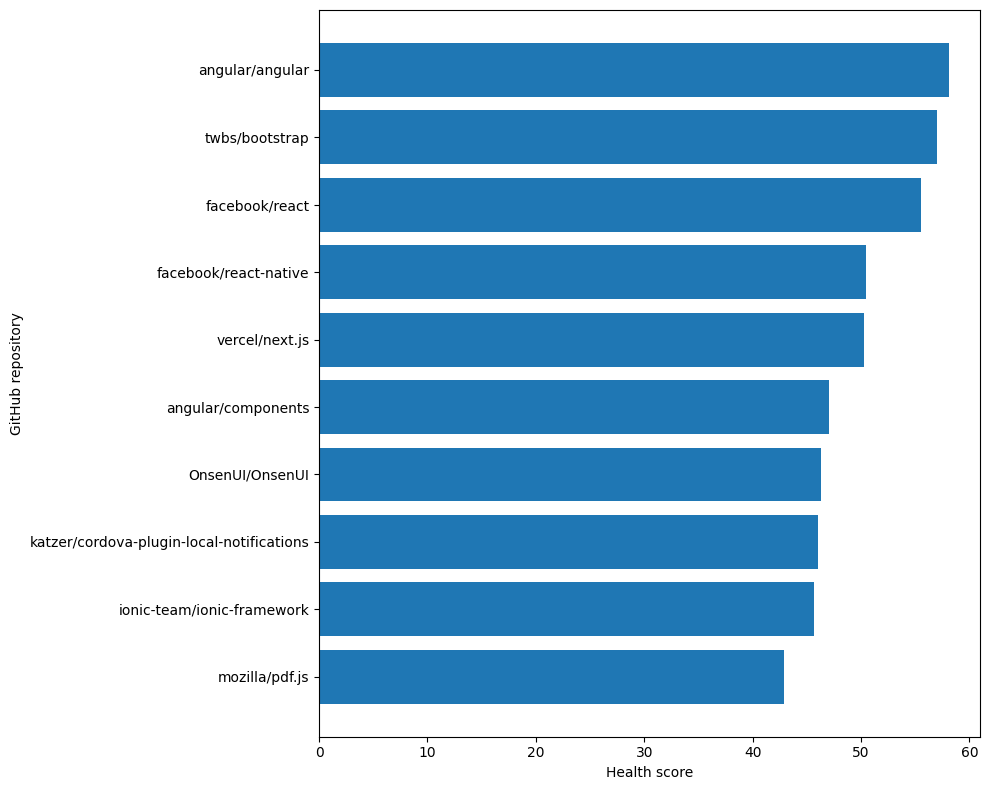

In [17]:
top_n = 10
plot_df = repo_enriched.sort_values('wang2022_health_score', ascending=False).head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(plot_df['github_repo_full_name'][::-1], plot_df['wang2022_health_score'][::-1])
plt.xlabel('Health score')
plt.ylabel('GitHub repository')
# plt.title(f'Top {top_n} repositories by popularity score')
plt.tight_layout()
save_current_figure('top_repositories_by_health_score.png')
plt.show()


Saved figure: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/repository_count_by_health_level.png


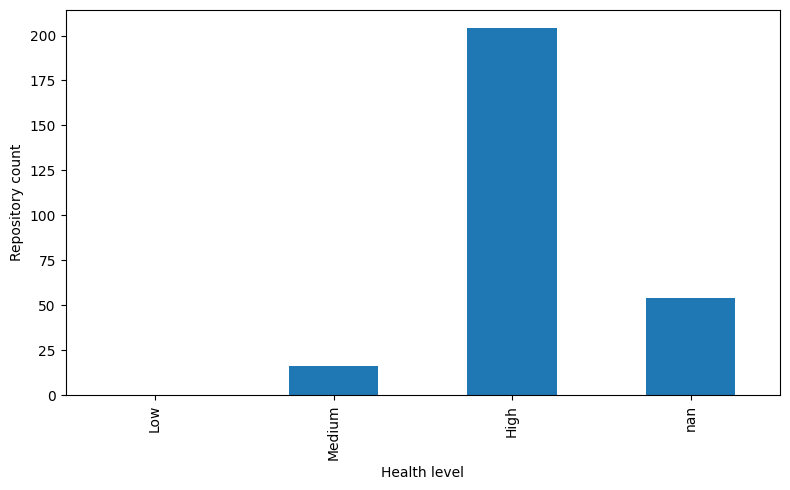

In [18]:
plt.figure(figsize=(8, 5))
repo_enriched['wang2022_health_level'].value_counts(dropna=False).sort_index().plot(kind='bar')
plt.xlabel('Health level')
plt.ylabel('Repository count')
# plt.title('Repository count by fragility level')
plt.tight_layout()
save_current_figure('repository_count_by_health_level.png')
plt.show()



In [19]:
repo_enriched['wang2022_health_level'].value_counts(dropna=False).sort_index()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


wang2022_health_level
Low         0
Medium     16
High      204
NaN        54
Name: count, dtype: int64

## 16. Final corpus questions — APK use of medium-fragility open source libraries

This final section joins the two analysis paths in this notebook:

1. **APK/library usage evidence** from `dataset_700.csv`, especially `pkg_name`, `repo_url`, `cited`, `origin`, and `classes_matched`.
2. **GitHub-based library fragility** from the enriched repository table, especially `fragility_score` and `fragility_level`.

The goal is to answer:

- Which APKs use open source libraries with **Medium** fragility?
- How intense is that use inside each APK?
- Which APKs use **Medium** fragility libraries but have `cited = 0`?
- How intense is the uncited use?

For intensity, this notebook uses:

\[
\text{intensity pct} = \frac{\text{classes\_matched for selected rows}}{\text{total classes\_matched for the APK}} \times 100
\]

A higher percentage means a larger share of that APK's detected open-source class usage comes from the selected medium-fragility libraries.

In [28]:
# -------------------------------------------------------------------
# Join row-level APK/library usage with repo-level GitHub fragility
# and app metadata from tagged_apps.csv
# -------------------------------------------------------------------

required_objects = ['df', 'repo_enriched', 'OUTPUT_DIR', 'TAGGED_APPS_FILE']
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        'Please run the previous notebook cells first. Missing objects: '
        + ', '.join(missing_objects)
    )

usage_df = df.copy()

if 'classes_matched' not in usage_df.columns:
    raise ValueError('Expected column not found: classes_matched')

usage_df['classes_matched_numeric'] = pd.to_numeric(
    usage_df['classes_matched'], errors='coerce'
).fillna(0)

# Total detected open-source class matches per APK.
apk_totals = (
    usage_df.groupby('pkg_name', dropna=False)['classes_matched_numeric']
    .sum()
    .reset_index(name='apk_total_classes_matched')
)

# App metadata: pkg_name is the identifier, app_name is the human-readable title.
# The file is expected at ../analysis_datasets/tagged_apps.csv.
if TAGGED_APPS_FILE.exists():
    tagged_apps = pd.read_csv(TAGGED_APPS_FILE)
    required_tagged_cols = ['pkg_name', 'app_name', 'downloads', 'category']
    missing_tagged_cols = [c for c in required_tagged_cols if c not in tagged_apps.columns]
    if missing_tagged_cols:
        raise ValueError(f'tagged_apps.csv is missing required columns: {missing_tagged_cols}')

    tagged_apps_lookup = (
        tagged_apps[required_tagged_cols]
        .drop_duplicates(subset=['pkg_name'])
        .copy()
    )
else:
    print(f'Warning: tagged_apps.csv not found at {TAGGED_APPS_FILE}. Falling back to pkg_name labels.')
    tagged_apps_lookup = pd.DataFrame({
        'pkg_name': usage_df['pkg_name'].drop_duplicates(),
        'app_name': usage_df['pkg_name'].drop_duplicates(),
        'downloads': np.nan,
        'category': 'Unknown',
    })


health_columns = [
    'github_repo_full_name',
    'wang2022_health_score',
    'wang2022_health_level',
    'wang2022_pressure_health',
    'wang2022_state_health',
    'wang2022_response_health',
]
health_columns = [c for c in health_columns if c in repo_enriched.columns]

repo_health_lookup = (
    repo_enriched[health_columns]
    .drop_duplicates(subset=['github_repo_full_name'])
)

usage_health_df = usage_df.merge(
    repo_health_lookup,
    on='github_repo_full_name',
    how='left'
).merge(
    apk_totals,
    on='pkg_name',
    how='left'
).merge(
    tagged_apps_lookup,
    on='pkg_name',
    how='left'
)

usage_health_df['app_name'] = usage_health_df['app_name'].fillna(usage_health_df['pkg_name'])
usage_health_df['category'] = usage_health_df['category'].fillna('Unknown')
usage_health_df['app_label'] = np.where(
    usage_health_df['app_name'].astype(str).str.strip().ne(''),
    usage_health_df['app_name'].astype(str),
    usage_health_df['pkg_name'].astype(str),
)

usage_health_df['row_intensity_pct_of_apk'] = np.where(
    usage_health_df['apk_total_classes_matched'] > 0,
    usage_health_df['classes_matched_numeric'] / usage_health_df['apk_total_classes_matched'] * 100,
    np.nan,
)

medium_health_rows = usage_health_df[
    usage_health_df['wang2022_health_level'].astype(str).str.lower().eq('medium')
].copy()

medium_health_uncited_rows = medium_health_rows[
    medium_health_rows['cited'].fillna(0).astype(int).eq(0)
].copy()

print('All dataset rows:', len(usage_health_df))
print('Rows joined to a GitHub health level:', usage_health_df['wang2022_health_level'].notna().sum())
print('Rows joined to app metadata:', usage_health_df['app_name'].notna().sum())
print('Medium-health usage rows:', len(medium_health_rows))
print('Medium-health uncited rows:', len(medium_health_uncited_rows))

medium_health_rows.head(10)


All dataset rows: 108234
Rows joined to a GitHub health level: 98330
Rows joined to app metadata: 108234
Medium-health usage rows: 225
Medium-health uncited rows: 69


,pkg_name,repo_host,repo_path,repo_url,cited,origin,libarary_key,library_name,smali_prefix,fingerprint_types,classes_matched,sample_class,sample_class_file,library_key,origin_fingerprint,origin_license_exposure,github_repo_full_name,classes_matched_numeric,wang2022_health_score,wang2022_health_level,wang2022_pressure_health,wang2022_state_health,wang2022_response_health,apk_total_classes_matched,app_name,downloads,category,app_label,row_intensity_pct_of_apk
1808,app.via1,NaN,NaN,"{'type': 'git', 'url': 'https://github.com/cha...",1,license_exposure,react-native-url-polyfill,react-native-url-polyfill,NaN,json_license_heuristic,NaN,NaN,data/decoded/app.via1/res/raw/node_modules_rea...,react-native-url-polyfill,0,1,charpeni/react-native-url-polyfill,0.0,29.698054,Medium,0.659725,0.066255,0.164962,37900.0,Friday: pagamento de contas,100K+,FINANCE,Friday: pagamento de contas,0.000000
1810,app.via1,NaN,NaN,https://github.com/charpeni/react-native-url-p...,1,license_exposure,charpeni/react-native-url-polyfill,charpeni/react-native-url-polyfill,NaN,generic_text_repo_url,NaN,NaN,data/decoded/app.via1/res/raw/node_modules_rea...,charpeni/react-native-url-polyfill,0,1,charpeni/react-native-url-polyfill,0.0,29.698054,Medium,0.659725,0.066255,0.164962,37900.0,Friday: pagamento de contas,100K+,FINANCE,Friday: pagamento de contas,0.000000
8363,ch.banklinth.twint,github.com,google/libphonenumber,https://github.com/google/libphonenumber,0,fingerprints,google/libphonenumber,libphonenumber,Lcom/google/i18n/phonenumbers/,java_package,51.0,Lcom/google/i18n/phonenumbers/AlternateFormats...,data/decoded/ch.banklinth.twint/smali_classes3...,google/libphonenumber,1,0,google/libphonenumber,51.0,26.509772,Medium,0.693832,0.078759,0.022702,21225.0,LLB Schweiz TWINT,1K+,FINANCE,LLB Schweiz TWINT,0.240283
8364,ch.banklinth.twint,github.com,google/libphonenumber,https://github.com/google/libphonenumber,0,fingerprints,google/libphonenumber,libphonenumber,Lcom/google/i18n/phonenumbers/internal/,java_package,5.0,Lcom/google/i18n/phonenumbers/internal/Matcher...,data/decoded/ch.banklinth.twint/smali_classes3...,google/libphonenumber,1,0,google/libphonenumber,5.0,26.509772,Medium,0.693832,0.078759,0.022702,21225.0,LLB Schweiz TWINT,1K+,FINANCE,LLB Schweiz TWINT,0.023557
8620,co.bitx.android.wallet,github.com,google/libphonenumber,https://github.com/google/libphonenumber,1,fingerprints,google/libphonenumber,libphonenumber,Lcom/google/i18n/phonenumbers/,java_package,67.0,Lcom/google/i18n/phonenumbers/AlternateFormats...,data/decoded/co.bitx.android.wallet/smali_clas...,google/libphonenumber,1,0,google/libphonenumber,67.0,26.509772,Medium,0.693832,0.078759,0.022702,37995.0,Luno: Buy Bitcoin & Crypto,10M+,FINANCE,Luno: Buy Bitcoin & Crypto,0.176339
8621,co.bitx.android.wallet,github.com,google/libphonenumber,https://github.com/google/libphonenumber,1,fingerprints,google/libphonenumber,libphonenumber,Lcom/google/i18n/phonenumbers/internal/,java_package,6.0,Lcom/google/i18n/phonenumbers/internal/GeoEnti...,data/decoded/co.bitx.android.wallet/smali_clas...,google/libphonenumber,1,0,google/libphonenumber,6.0,26.509772,Medium,0.693832,0.078759,0.022702,37995.0,Luno: Buy Bitcoin & Crypto,10M+,FINANCE,Luno: Buy Bitcoin & Crypto,0.015792
8622,co.bitx.android.wallet,github.com,google/libphonenumber,https://github.com/google/libphonenumber,1,fingerprints,google/libphonenumber,libphonenumber,Lcom/google/i18n/phonenumbers/metadata/,java_package,21.0,Lcom/google/i18n/phonenumbers/metadata/Default...,data/decoded/co.bitx.android.wallet/smali_clas...,google/libphonenumber,1,0,google/libphonenumber,21.0,26.509772,Medium,0.693832,0.078759,0.022702,37995.0,Luno: Buy Bitcoin & Crypto,10M+,FINANCE,Luno: Buy Bitcoin & Crypto,0.055270
8623,co.bitx.android.wallet,github.com,google/libphonenumber,https://github.com/google/libphonenumber,1,fingerprints,google/libphonenumber,libphonenumber,Lcom/google/i18n/phonenumbers/metadata/init/,java_package,2.0,Lcom/google/i18n/phonenumbers/metadata/in

### 16.1 APKs that use medium-fragility libraries

The table below aggregates each APK's use of medium-fragility repositories. The main intensity field is `medium_fragility_intensity_pct_of_apk`, which shows what percentage of the APK's total detected `classes_matched` comes from medium-fragility libraries.

In [29]:
def join_unique_values(values, max_items=12):
    cleaned = [str(v) for v in values.dropna().unique() if str(v).strip()]
    cleaned = sorted(cleaned)
    if len(cleaned) > max_items:
        return ', '.join(cleaned[:max_items]) + f', ... (+{len(cleaned) - max_items} more)'
    return ', '.join(cleaned)


def aggregate_apk_health_usage(rows: pd.DataFrame, prefix: str) -> pd.DataFrame:
    base_columns = [
        'pkg_name',
        'app_name',
        'app_label',
        'downloads',
        'category',
        f'{prefix}_rows',
        f'{prefix}_unique_repos',
        f'{prefix}_classes_matched',
        'apk_total_classes_matched',
        f'{prefix}_intensity_pct_of_apk',
    ]
    if rows.empty:
        return pd.DataFrame(columns=base_columns)

    agg = (
        rows.groupby('pkg_name', dropna=False)
        .agg(
            app_name=('app_name', 'first'),
            app_label=('app_label', 'first'),
            downloads=('downloads', 'first'),
            category=('category', 'first'),
            **{
                f'{prefix}_rows': ('pkg_name', 'size'),
                f'{prefix}_unique_repos': ('github_repo_full_name', 'nunique'),
                f'{prefix}_classes_matched': ('classes_matched_numeric', 'sum'),
                'apk_total_classes_matched': ('apk_total_classes_matched', 'first'),
                f'{prefix}_mean_health_score': ('wang2022_health_score', 'mean'),
                f'{prefix}_max_health_score': ('wang2022_health_score', 'max'),
                f'{prefix}_repos': ('github_repo_full_name', join_unique_values),
                f'{prefix}_library_names': ('library_name', join_unique_values) if 'library_name' in rows.columns else ('github_repo_full_name', join_unique_values),
            }
        )
        .reset_index()
    )

    agg[f'{prefix}_intensity_pct_of_apk'] = np.where(
        agg['apk_total_classes_matched'] > 0,
        agg[f'{prefix}_classes_matched'] / agg['apk_total_classes_matched'] * 100,
        np.nan,
    )

    return agg.sort_values(
        [f'{prefix}_intensity_pct_of_apk', f'{prefix}_classes_matched', f'{prefix}_unique_repos'],
        ascending=False,
    )

medium_apk_usage = aggregate_apk_health_usage(
    medium_health_rows,
    prefix='medium_health'
)

print('APKs using at least one medium-health library:', medium_apk_usage['pkg_name'].nunique())
medium_apk_usage.head(30)


APKs using at least one medium-health library: 89


,pkg_name,app_name,app_label,downloads,category,medium_health_rows,medium_health_unique_repos,medium_health_classes_matched,apk_total_classes_matched,medium_health_mean_health_score,medium_health_max_health_score,medium_health_repos,medium_health_library_names,medium_health_intensity_pct_of_apk
68,com.vtech.mobile.kidichat.frfre,KidiCom Chat™ (FR),KidiCom Chat™ (FR),100K+,COMMUNICATION,3,1,3.0,16.0,27.309936,27.309936,DataDog/dd-trace-php,dd-trace-php,18.750000
85,pt.cemah.online,CEMAH netCEM,CEMAH netCEM,10K+,FINANCE,9,5,61.0,3563.0,27.388169,29.843719,"DataDog/dd-trace-php, Regaddi/Chart.StackedBar...","Regaddi/Chart.StackedBar.js, dd-trace-php, inl...",1.712040
14,com.cerbotech.neurom,NeurOm,NeurOm,5K+,HEALTH_AND_FITNESS,5,1,115.0,20025.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.574282
17,com.cloudsimapp.vtl,Cloud SIM:Second Phone/2ndLine,Cloud SIM:Second Phone/2ndLine,500K+,COMMUNICATION,5,1,115.0,24560.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.468241
40,com.hotepgold.app,HotepGold – Commodity Trading,HotepGold – Commodity Trading,1+,FINANCE,5,2,8.0,1764.0,27.282160,27.309936,"DataDog/dd-trace-php, mohayonao/inline-worker","dd-trace-php, inline-worker",0.453515
60,com.simpplr.cb.saintgobain,SaintGobain - SGDD,SaintGobain - SGDD,10K+,COMMUNICATION,4,1,78.0,18205.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.428454
5,com.andoverbank.mobile,Andover Mobile Banking,Andover Mobile Banking,10K+,FINANCE,2,1,53.0,14259.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.371695
35,com.franklinbank.mobile,Franklin Bank,Franklin Bank,1K+,FINANCE,2,1,53.0,14259.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.371695
11,com.bt_prod.bad,Banque Transatlantique mobile,Banque Transatlantique mobile,10K+,FINANCE,2,1,56.0,15254.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.367117
72,de.bevestor.wrapperapp,bevestor,bevestor,10K+,FINANCE,2,1,56.0,15687.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.356983


### 16.2 APKs that use medium-health libraries but did not cite them

This table applies the same intensity logic, but only for medium-health rows where `cited = 0`. Two intensity percentages are useful:

- `medium_health_uncited_intensity_pct_of_apk`: uncited medium-health classes as a share of all detected open-source class matches in the APK.
- `uncited_share_of_medium_health_classes_pct`: among the APK's medium-health class matches, the percentage that came from uncited rows.

In [43]:
medium_uncited_apk_usage = aggregate_apk_health_usage(
    medium_health_uncited_rows,
    prefix='medium_health_uncited'
)

# Add context from all medium-health usage for the same APK.
context_cols = [
    'pkg_name',
    'medium_health_rows',
    'medium_health_unique_repos',
    'medium_health_classes_matched',
    'medium_health_intensity_pct_of_apk',
]
context_cols = [c for c in context_cols if c in medium_apk_usage.columns]

medium_uncited_apk_usage = medium_uncited_apk_usage.merge(
    medium_apk_usage[context_cols],
    on='pkg_name',
    how='left'
)

medium_uncited_apk_usage['uncited_share_of_medium_health_classes_pct'] = np.where(
    medium_uncited_apk_usage['medium_health_classes_matched'] > 0,
    medium_uncited_apk_usage['medium_health_uncited_classes_matched'] /
    medium_uncited_apk_usage['medium_health_classes_matched'] * 100,
    np.nan,
)

medium_uncited_apk_usage = medium_uncited_apk_usage.sort_values(
    [
        'medium_health_uncited_intensity_pct_of_apk',
        'uncited_share_of_medium_health_classes_pct',
        'medium_health_uncited_classes_matched',
    ],
    ascending=False,
)

print('APKs using at least one uncited medium-health library:', medium_uncited_apk_usage['pkg_name'].nunique())
medium_uncited_apk_usage.head(35)


APKs using at least one uncited medium-health library: 34


,pkg_name,app_name,app_label,downloads,category,medium_health_uncited_rows,medium_health_uncited_unique_repos,medium_health_uncited_classes_matched,apk_total_classes_matched,medium_health_uncited_mean_health_score,medium_health_uncited_max_health_score,medium_health_uncited_repos,medium_health_uncited_library_names,medium_health_uncited_intensity_pct_of_apk,medium_health_rows,medium_health_unique_repos,medium_health_classes_matched,medium_health_intensity_pct_of_apk,uncited_share_of_medium_health_classes_pct
0,com.hotepgold.app,HotepGold – Commodity Trading,HotepGold – Commodity Trading,1+,FINANCE,5,2,8.0,1764.0,27.282160,27.309936,"DataDog/dd-trace-php, mohayonao/inline-worker","dd-trace-php, inline-worker",0.453515,5,2,8.0,0.453515,100.0
1,de.bevestor.wrapperapp,bevestor,bevestor,10K+,FINANCE,2,1,56.0,15687.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.356983,2,1,56.0,0.356983,100.0
2,dubai.rta,Dubai Bus on Demand,Dubai Bus on Demand,100K+,MAPS_AND_NAVIGATION,5,1,115.0,36666.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.313642,5,1,115.0,0.313642,100.0
3,com.mdlive.FHN_mobile,FHN Now,FHN Now,1K+,MEDICAL,5,1,115.0,39626.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.290213,5,1,115.0,0.290213,100.0
4,ch.banklinth.twint,LLB Schweiz TWINT,LLB Schweiz TWINT,1K+,FINANCE,2,1,56.0,21225.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.263840,2,1,56.0,0.263840,100.0
5,com.opngo.live,INDIGO Neo City Parking,INDIGO Neo City Parking,1M+,MAPS_AND_NAVIGATION,1,1,37.0,15244.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.242718,1,1,37.0,0.242718,100.0
6,com.moundcitybank.mobile,Mound City Bank,Mound City Bank,1K+,FINANCE,2,1,53.0,22381.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.236808,2,1,53.0,0.236808,100.0
7,jp.okaimono,お買い物電卓 〜価格比較・割引計算アプリ〜,お買い物電卓 〜価格比較・割引計算アプリ〜,50K+,FINANCE,5,2,18.0,8079.0,27.282160,27.309936,"DataDog/dd-trace-php, mohayonao/inline-worker","dd-trace-php, inline-worker",0.222800,5,2,18.0,0.222800,100.0
8,com.dhan.live,Dhan: Share Market Trading App,Dhan: Share Market Trading App,10M+,FINANCE,2,1,28.0,19651.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.142486,2,1,28.0,0.142486,100.0
9,com.hst.hstmobile2,HST Connect,HST Connect,5K+,HEALTH_AND_FITNESS,4,1,4.0,2888.0,27.309936,27.309936,DataDog/dd-trace-php,dd-trace-php,0.138504,6,3,8.0,0.277008,50.0


### 16.3 Row-level evidence for auditing

The next exports preserve the row-level evidence behind the APK summaries. Use these files to inspect exactly which libraries contributed to each APK's medium-health or uncited-medium-health intensity.

In [31]:
# -------------------------------------------------------------------
# Export APK-level summaries and row-level evidence
# -------------------------------------------------------------------

MEDIUM_APK_USAGE_OUTPUT = OUTPUT_DIR / 'dataset_700_medium_health_apk_usage.csv'
MEDIUM_UNCITED_APK_USAGE_OUTPUT = OUTPUT_DIR / 'dataset_700_medium_health_uncited_apk_usage.csv'
MEDIUM_ROW_DETAILS_OUTPUT = OUTPUT_DIR / 'dataset_700_medium_health_row_details.csv'
MEDIUM_UNCITED_ROW_DETAILS_OUTPUT = OUTPUT_DIR / 'dataset_700_medium_health_uncited_row_details.csv'

medium_apk_usage.to_csv(MEDIUM_APK_USAGE_OUTPUT, index=False)
medium_uncited_apk_usage.to_csv(MEDIUM_UNCITED_APK_USAGE_OUTPUT, index=False)
medium_health_rows.to_csv(MEDIUM_ROW_DETAILS_OUTPUT, index=False)
medium_health_uncited_rows.to_csv(MEDIUM_UNCITED_ROW_DETAILS_OUTPUT, index=False)

print('Saved:', MEDIUM_APK_USAGE_OUTPUT)
print('Saved:', MEDIUM_UNCITED_APK_USAGE_OUTPUT)
print('Saved:', MEDIUM_ROW_DETAILS_OUTPUT)
print('Saved:', MEDIUM_UNCITED_ROW_DETAILS_OUTPUT)

Saved: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/dataset_700_medium_health_apk_usage.csv
Saved: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/dataset_700_medium_health_uncited_apk_usage.csv
Saved: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/dataset_700_medium_health_row_details.csv
Saved: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/dataset_700_medium_health_uncited_row_details.csv


### 16.4 Visual summary

These charts show the APKs with the highest medium-health intensity and the APKs with the highest uncited medium-health intensity.

In [36]:
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
import matplotlib as mpl

candidate_fonts = [
    'Hiragino Sans',
    'Hiragino Maru Gothic Pro',
    'Yu Gothic',
    'Noto Sans CJK JP',
    'Noto Sans JP',
    'IPAexGothic',
    'AppleGothic',
]

available_fonts = {f.name for f in fm.fontManager.ttflist}

for font in candidate_fonts:
    if font in available_fonts:
        mpl.rcParams['font.family'] = font
        break

mpl.rcParams['axes.unicode_minus'] = False

def plot_category_colored_barh(
    plot_df: pd.DataFrame,
    value_col: str,
    title: str,
    xlabel: str,
    output_filename: str
):
    if plot_df.empty:
        print(f'No data available for {title}.')
        return

    plot_df = plot_df.copy()
    plot_df['category'] = plot_df['category'].fillna('Unknown').astype(str)
    plot_df['app_label'] = plot_df['app_label'].fillna(plot_df['pkg_name']).astype(str)

    categories = sorted(plot_df['category'].unique())

    # Create blue shades based on Matplotlib default blue: #1f77b4
    base_blue = '#1f77b4'
    blue_shades = [
        mcolors.to_hex(
            np.array(mcolors.to_rgb(base_blue)) * factor
            + np.array([1, 1, 1]) * (1 - factor)
        )
        for factor in np.linspace(0.35, 1.0, len(categories))
    ]

    category_color_map = {
        category: blue_shades[i]
        for i, category in enumerate(categories)
    }

    colors = plot_df['category'].map(category_color_map)

    plt.figure(figsize=(12, max(6, len(plot_df) * 0.4)))
    plt.barh(plot_df['app_label'], plot_df[value_col], color=colors)
    plt.xlabel(xlabel)
    plt.ylabel('App name')
    # plt.title(title)

    legend_handles = [
        mpatches.Patch(color=category_color_map[category], label=category)
        for category in categories
    ]

    plt.legend(
        handles=legend_handles,
        title='Category',
        loc='lower right',
        bbox_to_anchor=(0.98, 0.02),
        frameon=True
    )

    plt.tight_layout()
    save_current_figure(output_filename)
    plt.show()

In [41]:
medium_apk_usage.head()

,pkg_name,app_name,app_label,downloads,category,medium_health_rows,medium_health_unique_repos,medium_health_classes_matched,apk_total_classes_matched,medium_health_mean_health_score,medium_health_max_health_score,medium_health_repos,medium_health_library_names,medium_health_intensity_pct_of_apk
68,com.vtech.mobile.kidichat.frfre,KidiCom Chat™ (FR),KidiCom Chat™ (FR),100K+,COMMUNICATION,3,1,3.0,16.0,27.309936,27.309936,DataDog/dd-trace-php,dd-trace-php,18.750000
85,pt.cemah.online,CEMAH netCEM,CEMAH netCEM,10K+,FINANCE,9,5,61.0,3563.0,27.388169,29.843719,"DataDog/dd-trace-php, Regaddi/Chart.StackedBar...","Regaddi/Chart.StackedBar.js, dd-trace-php, inl...",1.712040
14,com.cerbotech.neurom,NeurOm,NeurOm,5K+,HEALTH_AND_FITNESS,5,1,115.0,20025.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.574282
17,com.cloudsimapp.vtl,Cloud SIM:Second Phone/2ndLine,Cloud SIM:Second Phone/2ndLine,500K+,COMMUNICATION,5,1,115.0,24560.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.468241
40,com.hotepgold.app,HotepGold – Commodity Trading,HotepGold – Commodity Trading,1+,FINANCE,5,2,8.0,1764.0,27.282160,27.309936,"DataDog/dd-trace-php, mohayonao/inline-worker","dd-trace-php, inline-worker",0.453515


Saved figure: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/top_apps_by_medium_health_intensity.png


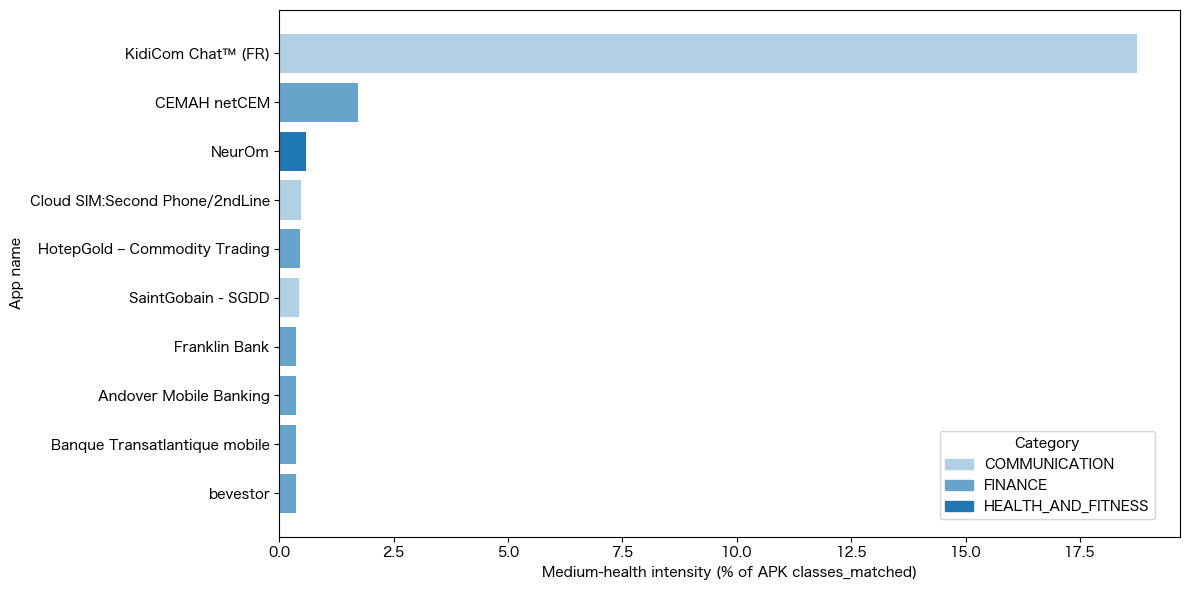

In [37]:
# Top APKs by medium-health intensity, using app_name labels and category colors.
plot_top_n = 10

plot_df = medium_apk_usage.head(plot_top_n).sort_values(
    'medium_health_intensity_pct_of_apk', ascending=True
)

plot_category_colored_barh(
    plot_df=plot_df,
    value_col='medium_health_intensity_pct_of_apk',
    title=f'Top {min(plot_top_n, len(plot_df))} apps by medium-health library usage intensity',
    xlabel='Medium-health intensity (% of APK classes_matched)',
    output_filename='top_apps_by_medium_health_intensity.png',
)


In [42]:
medium_uncited_apk_usage.head()

,pkg_name,app_name,app_label,downloads,category,medium_health_uncited_rows,medium_health_uncited_unique_repos,medium_health_uncited_classes_matched,apk_total_classes_matched,medium_health_uncited_mean_health_score,medium_health_uncited_max_health_score,medium_health_uncited_repos,medium_health_uncited_library_names,medium_health_uncited_intensity_pct_of_apk,medium_health_rows,medium_health_unique_repos,medium_health_classes_matched,medium_health_intensity_pct_of_apk,uncited_share_of_medium_health_classes_pct
0,com.hotepgold.app,HotepGold – Commodity Trading,HotepGold – Commodity Trading,1+,FINANCE,5,2,8.0,1764.0,27.282160,27.309936,"DataDog/dd-trace-php, mohayonao/inline-worker","dd-trace-php, inline-worker",0.453515,5,2,8.0,0.453515,100.0
1,de.bevestor.wrapperapp,bevestor,bevestor,10K+,FINANCE,2,1,56.0,15687.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.356983,2,1,56.0,0.356983,100.0
2,dubai.rta,Dubai Bus on Demand,Dubai Bus on Demand,100K+,MAPS_AND_NAVIGATION,5,1,115.0,36666.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.313642,5,1,115.0,0.313642,100.0
3,com.mdlive.FHN_mobile,FHN Now,FHN Now,1K+,MEDICAL,5,1,115.0,39626.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.290213,5,1,115.0,0.290213,100.0
4,ch.banklinth.twint,LLB Schweiz TWINT,LLB Schweiz TWINT,1K+,FINANCE,2,1,56.0,21225.0,26.509772,26.509772,google/libphonenumber,libphonenumber,0.263840,2,1,56.0,0.263840,100.0


Saved figure: /Users/shayan/Documents/Corvinus Works/2025-02/Thesis Work 1/Analysis-System-Open-Source-Library-in-APKs/notebook/../analysis_outputs/top_apps_by_uncited_medium_health_intensity.png


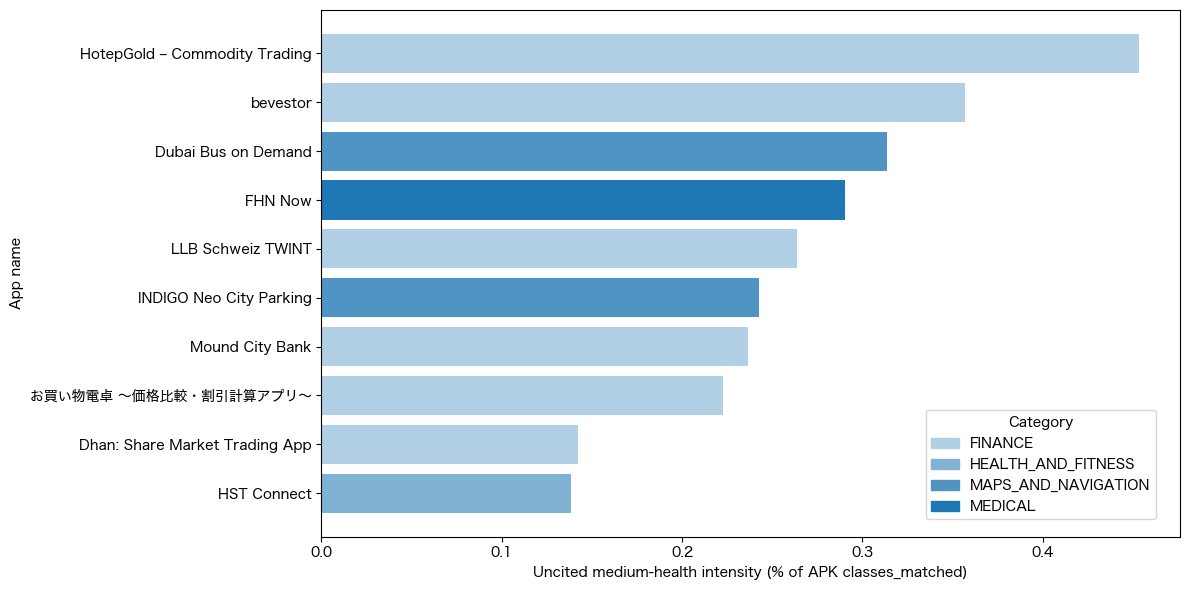

In [38]:
# Top APKs by uncited medium-health intensity, using app_name labels and category colors.
plot_df = medium_uncited_apk_usage.head(plot_top_n).sort_values(
    'medium_health_uncited_intensity_pct_of_apk', ascending=True
)

plot_category_colored_barh(
    plot_df=plot_df,
    value_col='medium_health_uncited_intensity_pct_of_apk',
    title=f'Top {min(plot_top_n, len(plot_df))} apps by uncited medium-health usage intensity',
    xlabel='Uncited medium-health intensity (% of APK classes_matched)',
    output_filename='top_apps_by_uncited_medium_health_intensity.png',
)


### 16.5 Interpretation notes

- `classes_matched` is treated as the available proxy for usage intensity.
- Rows with missing `classes_matched` are counted as `0` for class-based intensity. This avoids inflating intensity from license-text-only evidence where no matched class count is available.
- If one APK has multiple rows for the same repository because several prefixes or fingerprint types matched, this analysis sums those rows because each row represents detected usage evidence in the original dataset.
- `Medium` health comes from the `health_level` already calculated earlier in this notebook from GitHub repository metadata.